<a href="https://colab.research.google.com/github/KatsJohn/GDP_prediction/blob/main/GDP_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Global GDP Insights — ML + Data Analysis Project

## 🧠 Project Overview

You are a **Junior Data Scientist and Economic Analyst** working at the **Global Economic Insights Forum (GEIF)** — an international analytical body that advises policymakers and organizations on global economic trends.

Your task is to use the **Country, Regional and World GDP** dataset to explore economic patterns, build predictive models, and craft a professional analytical briefing. You may **supplement your work with auxiliary data** (e.g., population or inflation data from the World Bank) *if it helps your analysis* — but the **core work must use the GDP dataset provided**.

<br></br>

## 📦 Dataset Description

**Dataset:** *Country, Regional and World GDP (Gross Domestic Product)*  
**Source:** DataHub (World Bank / OECD main sources) :contentReference[oaicite:0]{index=0}  

**Schema:**
- `Country Name` — country or region  
- `Country Code` — ISO and regional codes :contentReference[oaicite:1]{index=1}  
- `Year` — annual observation  
- `Value` — GDP in **current US dollars ($)** :contentReference[oaicite:2]{index=2}  

**Important context:**  
The data shows **nominal GDP** (not adjusted for inflation). This means changes over time can reflect both real output shifts *and* price/valuation changes. Be sure to mention this caveat in your analysis. :contentReference[oaicite:3]{index=3}

<br></br>


## 🎯 Project Objectives

### ✅ Objective 1 — Data Audit & Cleaning
- Load the GDP dataset and inspect its structure.
- Report missing values, unusual codes, or coverage gaps.
- Decide and document how you handle missing years for selected countries.
- (Optional) Add auxiliary information like population data to compute per-capita metrics.


<br></br>


### 📊 Objective 2 — EDA & Economic Storytelling

Use visualizations and descriptive statistics to answer:

1. **Which countries/regions have the largest GDP levels?**  
2. **Which have grown the fastest (in percent terms) over time?**


<br></br>


### 📈 Objective 3 — ML Forecasting (2 Clear ML Goals)

You must build and evaluate **two distinct ML forecasting models** to predict future GDP:

**ML Goal A — Baseline & Linear Forecast**
- Train a simple model (e.g., **linear regression on Year**) to forecast the next 5 years of GDP for **3 selected countries/regions**.
- Show training vs test performance, and produce forecast plots.

**ML Goal B — Advanced Time Series Model**
- Use an advanced forecasting model such as:
  - **ARIMA**
  - **Prophet**
  - **LSTM**
- Compare performance with the baseline.

For both:
- Use a time-based train/test split.
- Report metrics (e.g., MAE or RMSE).
- Interpret model results and limitations.


<br></br>


### 🔁 Objective 4 — Correlation & Co-Movement

Investigate whether selected countries/regions move together economically:

- Compute **correlation matrices** on **growth rates**, not raw GDP levels.
- Visualize co-movement (e.g., heatmap).
- Identify at least **two interesting pairings** and propose reasons (trade links, shared shocks, geographic proximity).


<br></br>






## 🧪 Success Criteria

Your project will be evaluated on:
- **Correctness:** proper handling of time series and model evaluation.
- **Clarity:** clear charts, labeling, and explanations.
- **Economic judgment:** thoughtful interpretation and linking data patterns to real events.
- **ML rigor:** comparison of models with metrics and clear justification.

<br></br>



# Imports

In [ ]:
import os
# Data handling
import pandas as pd
pd.set_option("display.max_rows",None)
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet


# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, mean_squared_error, r2_score, mean_absolute_error,
    mean_absolute_percentage_error, root_mean_squared_error
)

# Set style
plt.style.use('ggplot')
sns.set_palette("husl")

print("All libraries imported successfully! ✓")

All libraries imported successfully! ✓


In [ ]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
gdp_df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI Machine Learning/AI_Online_Csv/gdp.csv")

In [ ]:
population_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI Machine Learning/AI_Online_Csv/population.csv")

In [ ]:
df = pd.merge(gdp_df,population_df,how='left',on=['Country Name','Country Code','Year'])

In [ ]:
df['GDP per Capita'] = df['Value']/df['Population']

# Basic Datset Characteristics

In [ ]:
df.head()

,Country Name,Country Code,Year,Value,Population,GDP per Capita
0,Afghanistan,AFG,2000,3.521418e+09,20130327.0,174.930991
1,Afghanistan,AFG,2001,2.813572e+09,20284307.0,138.706822
2,Afghanistan,AFG,2002,3.825701e+09,21378117.0,178.954088
3,Afghanistan,AFG,2003,4.520947e+09,22733049.0,198.871116
4,Afghanistan,AFG,2004,5.224897e+09,23560654.0,221.763654


In [ ]:
df.tail()

,Country Name,Country Code,Year,Value,Population,GDP per Capita
13974,Zimbabwe,ZWE,2019,2.183223e+10,15271368.0,1429.618809
13975,Zimbabwe,ZWE,2020,2.150970e+10,15526888.0,1385.319351
13976,Zimbabwe,ZWE,2021,2.837124e+10,15797210.0,1795.965152
13977,Zimbabwe,ZWE,2022,2.736663e+10,16069056.0,1703.063774
13978,Zimbabwe,ZWE,2023,2.653827e+10,16340822.0,1624.047646


In [ ]:
df.dtypes

,0
Country Name,object
Country Code,object
Year,int64
Value,float64
Population,float64
GDP per Capita,float64


In [ ]:
string_col = df.select_dtypes(include="object").columns
print(string_col)
num_col=df.columns.to_list()
for col in string_col:
    num_col.remove(col)
num_col.remove("Value")
print(num_col)

Index(['Country Name', 'Country Code'], dtype='object')
['Year', 'Population', 'GDP per Capita']


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,13979.0,1.994673e+03,1.773141e+01,1960.000000,1.980000e+03,1.996000e+03,2.010000e+03,2.023000e+03
Value,13979.0,1.207380e+12,5.537517e+12,11502.632645,2.233880e+09,1.672591e+10,2.058542e+11,1.054350e+14
Population,13979.0,2.573211e+08,7.763089e+08,5663.000000,1.775672e+06,8.668067e+06,6.438646e+07,8.061876e+09
GDP per Capita,13979.0,8.475376e+03,1.697329e+04,0.002425,5.792916e+02,1.935293e+03,7.960194e+03,2.256300e+05


In [ ]:
df.shape

(13979, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979 entries, 0 to 13978
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    13979 non-null  object 
 1   Country Code    13979 non-null  object 
 2   Year            13979 non-null  int64  
 3   Value           13979 non-null  float64
 4   Population      13979 non-null  float64
 5   GDP per Capita  13979 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 655.4+ KB


In [ ]:
df["Country Name"].nunique()

262

In [ ]:
df["Country Name"].unique()

array(['Afghanistan', 'Africa Eastern and Southern',
       'Africa Western and Central', 'Albania', 'Algeria',
       'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda',
       'Arab World', 'Argentina', 'Armenia', 'Aruba', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Caribbean small states', 'Cayman Islands',
       'Central African Republic', 'Central Europe and the Baltics',
       'Chad', 'Channel Islands', 'Chile', 'China', 'Colombia', 'Comoros',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czechia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic',
       'Early-demogr

In [ ]:
df["Country Name"].value_counts()

,count
Country Name,
Zimbabwe,64
Zambia,64
Africa Eastern and Southern,64
Africa Western and Central,64
Turkiye,64
Trinidad and Tobago,64
Benin,64
Togo,64
Thailand,64


In [ ]:
df["Country Name"].value_counts().value_counts().sort_index()

,count
count,
4,1
8,1
12,1
13,1
16,1
17,2
19,1
20,2
21,2


In [ ]:
df["Country Name"].value_counts().eq(64).sum()

np.int64(134)

In [ ]:
df.duplicated().sum()

np.int64(0)

# Data Quality Analysis Report: Global GDP Dataset
## Overview
This dataset covers the period from 1960 to 2023 showcasing the GDP of several countries and regions through this time.

## Unusual Codes & Aggregations
While the dataset is primarily about countries, it contains several peculiar codes that represent regions or income groups. These should be put into a different datset by themselves in order to avoid double-counting and to check both economic rises in countris' and regions' economies.

- Regional Aggregates: WLD (World), ARB (Arab World), EAP (East Asia & Pacific) etc. .

- Income Groups: HIC (High Income), LIC (Low Income), MIC (Middle Income), LDC (Least Developed Countries).

- Other Groupings: OED (OECD Members), IBT (IDA & IBRD Total), HPC (Heavily Indebted Poor Countries).

## Missing & Invalid Values
- Null Values: There are no missing values in the dataset

- Zero GDP: All recorded GDP values are positive. There are no rows with 0 or negative values.

## Coverage Gaps
Data continuity varies significantly by country. I have identified two types of gaps:

- Temporal Gaps (Missing Intermediate Years)
The following entities have breaks in their time series (missing years between their first and last recorded entry):

  - Channel Islands (CHI): Missing 8 years.

  - St. Martin (French part) (MAF): Missing 7 years (data available only for 2011, 2014, and 2021).

  - Iran (IRN) & Equatorial Guinea (GNQ): Missing 2 years.

  - Djibouti (DJI) & Solomon Islands (SLB): Missing 1 year.

- Short Coverage (Insufficient Historical Data)
Some countries have very limited data points compared to the full 63-year time period:

  - St. Martin (MAF): Only 4 years of total data.

  - South Sudan (SSD): Only 8 years of data (2008-2015).


## Recommendation

For this specific project,I recommend:

- Seperating the aggregated codes from the country countries in order to ensure clarity.

- Computing missing values for countries with minor gaps using linear estimations.

- Dropping countries/organizations with severe gaps or insufficient history (e.g. South Sudan) if they do not offer sufficient information for the mode;.

# EDA

In [ ]:
df_2023 = df[df['Year'] == 2023]
df_2023_sorted = df_2023.sort_values(by='Value', ascending=False)
print("Top 15 Countries by GDP in 2023:")
df_2023_sorted.head(15)

Top 15 Countries by GDP in 2023:


,Country Name,Country Code,Year,Value,Population,GDP per Capita
13821,World,WLD,2023,1.054350e+14,8.061876e+09,13078.226395
5301,High income,HIC,2023,6.765374e+13,1.400466e+09,48308.039560
9698,OECD members,OED,2023,6.409887e+13,1.385723e+09,46256.609100
10438,Post-demographic dividend,PST,2023,5.985180e+13,1.119236e+09,53475.578311
5613,IDA & IBRD total,IBT,2023,4.155972e+13,6.858957e+09,6059.189577
5549,IBRD only,IBD,2023,3.873304e+13,4.952574e+09,7820.790176
7525,Low & middle income,LMY,2023,3.742521e+13,6.633110e+09,5642.182412
8624,Middle income,MIC,2023,3.678694e+13,5.896643e+09,6238.624353
3216,East Asia & Pacific,EAS,2023,3.077566e+13,2.384464e+09,12906.743075
9517,North America,NAC,2023,2.950930e+13,3.750774e+08,78675.227329


In [ ]:
df_2023_sorted_per_capita = df_2023.sort_values(by='GDP per Capita',ascending=False)
print("Top 15 Countries by GDP per Capita in 2023:")
df_2023_sorted_per_capita.head(15)

Top 15 Countries by GDP per Capita in 2023:


,Country Name,Country Code,Year,Value,Population,GDP per Capita
7697,Luxembourg,LUX,2023,8.575501e+10,666430.0,128678.189943
6180,Ireland,IRL,2023,5.456295e+11,5307600.0,102801.539378
12445,Switzerland,CHE,2023,8.849404e+11,8888093.0,99564.710026
9634,Norway,NOR,2023,4.855133e+11,5519594.0,87961.780614
11238,Singapore,SGP,2023,5.014275e+11,5917648.0,84734.255921
13403,United States,USA,2023,2.736094e+13,334914895.0,81695.187071
5869,Iceland,ISL,2023,3.102003e+10,393349.0,78861.348531
9517,North America,NAC,2023,2.950930e+13,375077354.0,78675.227329
7739,"Macao SAR, China",MAC,2023,4.706184e+10,678800.0,69330.942422
2939,Denmark,DNK,2023,4.041988e+11,5946952.0,67967.381869


In [ ]:
non_country_entities = [
    'World', 'High income', 'OECD members', 'Post-demographic dividend',
    'IDA & IBRD total', 'IBRD only', 'Low & middle income', 'Middle income',
    'East Asia & Pacific', 'North America', 'European Union', 'Euro area',
    'Europe & Central Asia', 'Sub-Saharan Africa', 'Latin America & Caribbean',
    'South Asia', 'Early-demographic dividend', 'Pre-demographic dividend',
    'Least developed countries: UN classification', 'Fragile and conflict affected situations',
    'Africa Eastern and Southern', 'Africa Western and Central', 'Arab World',
    'Caribbean small states', 'Central Europe and the Baltics', 'Channel Islands',
    'East Asia & Pacific (IDA & IBRD countries)', 'East Asia & Pacific (excluding high income)',
    'Europe & Central Asia (IDA & IBRD countries)', 'Europe & Central Asia (excluding high income)',
    'Heavily indebted poor countries (HIPC)', 'IDA blend', 'IDA only', 'IDA total',
    'Late-demographic dividend', 'Latin America & Caribbean (excluding high income)',
    'Latin America & the Caribbean (IDA & IBRD countries)', 'Lower middle income',
    'Middle East & North Africa', 'Middle East & North Africa (IDA & IBRD countries)',
    'Middle East & North Africa (excluding high income)', 'North Africa',
    'Northern Mariana Islands', 'Other small states', 'Pacific island small states',
    'Small states', 'South Asia (IDA & IBRD)', 'Sub-Saharan Africa (IDA & IBRD countries)',
    'Sub-Saharan Africa (excluding high income)', 'Upper middle income'
]

df_2023_countries = df_2023_sorted[~df_2023_sorted['Country Name'].isin(non_country_entities)]
top_15_countries_gdp = df_2023_countries.head(15)

print("Top 15 Countries by GDP in 2023 (excluding non-country entities):")
print(top_15_countries_gdp)

fig = px.histogram(
    top_15_countries_gdp,
    x='Value',
    y='Country Name',
    title='Top 15 Countries by GDP in 2023',
    labels={'Country Name': 'Country', 'Value': 'GDP'},
    hover_data=['Country Code']
)
fig.show()

Top 15 Countries by GDP in 2023 (excluding non-country entities):
             Country Name Country Code  Year         Value    Population  \
13403       United States          USA  2023  2.736094e+13  3.349149e+08   
2363                China          CHN  2023  1.779478e+13  1.410710e+09   
4625              Germany          DEU  2023  4.456081e+12  8.328000e+07   
6463                Japan          JPN  2023  4.212945e+12  1.245166e+08   
5933                India          IND  2023  3.549919e+12  1.438070e+09   
13339      United Kingdom          GBR  2023  3.340032e+12  6.835000e+07   
4344               France          FRA  2023  3.030904e+12  6.828749e+07   
6335                Italy          ITA  2023  2.254851e+12  5.899348e+07   
1523               Brazil          BRA  2023  2.173666e+12  2.111407e+08   
1975               Canada          CAN  2023  2.140086e+12  4.009776e+07   
10692  Russian Federation          RUS  2023  2.021421e+12  1.438261e+08   
8321               Mex

In [ ]:
df_2023_countries_by_gdp_per_capita = df_2023_sorted_per_capita[~df_2023_sorted_per_capita['Country Name'].isin(non_country_entities)]
top_15_countries_gdp_per_capita = df_2023_countries_by_gdp_per_capita.head(15)

print("Top 15 Countries by GDP / Capita in 2023 (excluding non-country entities):")
print(top_15_countries_gdp_per_capita)

fig = px.histogram(
    top_15_countries_gdp_per_capita,
    x='GDP per Capita',
    y='Country Name',
    title='Top 15 Countries by GDP / Capita in 2023',
    labels={'Country Name': 'Country', 'GDP per Capita': 'GDP per capita'},
    hover_data=['Country Code']
)
fig.show()

Top 15 Countries by GDP / Capita in 2023 (excluding non-country entities):
           Country Name Country Code  Year         Value   Population  \
7697         Luxembourg          LUX  2023  8.575501e+10     666430.0   
6180            Ireland          IRL  2023  5.456295e+11    5307600.0   
12445       Switzerland          CHE  2023  8.849404e+11    8888093.0   
9634             Norway          NOR  2023  4.855133e+11    5519594.0   
11238         Singapore          SGP  2023  5.014275e+11    5917648.0   
13403     United States          USA  2023  2.736094e+13  334914895.0   
5869            Iceland          ISL  2023  3.102003e+10     393349.0   
7739   Macao SAR, China          MAC  2023  4.706184e+10     678800.0   
2939            Denmark          DNK  2023  4.041988e+11    5946952.0   
642           Australia          AUS  2023  1.723827e+12   26658948.0   
9167        Netherlands          NLD  2023  1.118125e+12   17877117.0   
706             Austria          AUT  2023  5.160

In [ ]:
country_names = top_15_countries_gdp['Country Name'].tolist()
top_5_countries = country_names[:5]
next_10_countries = country_names[5:]

print(top_5_countries)
print( next_10_countries)
df_top_5_all_years = df[df['Country Name'].isin(top_5_countries)]
df_next_10_all_years = df[df['Country Name'].isin(next_10_countries)]

['United States', 'China', 'Germany', 'Japan', 'India']
['United Kingdom', 'France', 'Italy', 'Brazil', 'Canada', 'Russian Federation', 'Mexico', 'Australia', 'Korea, Rep.', 'Spain']


In [ ]:
gdp_2023_top_5 = top_15_countries_gdp[:5].sort_values(by='Value', ascending=False)
desired_order = gdp_2023_top_5['Country Name'].tolist()
fig_top_5 = px.line(
    df_top_5_all_years,
    x='Year',
    y='Value',
    color='Country Name',
    title='GDP Evolution Over Time for Top 5 Economies',
    labels={'Value': 'GDP (current USD)', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code'],
    category_orders={'Country Name': desired_order}
)
fig_top_5.show()

In [ ]:
gdp_2023_next_10 = top_15_countries_gdp[5:].sort_values(by='Value', ascending=False)
desired_order = gdp_2023_next_10['Country Name'].tolist()

fig_next_10 = px.line(
    df_next_10_all_years,
    x='Year',
    y='Value',
    color='Country Name',
    title='GDP Evolution Over Time for Next 10 Economies',
    labels={'Value': 'GDP (current USD)', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code'],
    category_orders={'Country Name': desired_order}
)
fig_next_10.show()

#Greece GDP comparison

In [ ]:
selected_entities = ['Greece', 'Croatia', 'Ireland', 'Portugal', 'Hungary']
df_selected_entities = df[df['Country Name'].isin(selected_entities)]

fig_gdp = px.line(
    df_selected_entities,
    x='Year',
    y='Value',
    color='Country Name',
    title='GDP Evolution Over Time for Greece, Hungary, Croatia, Portugal and Ireland',
    labels={'Value': 'GDP (current USD)', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code']
)
fig_gdp.show()

fig_gdp_per_capita = px.line(
    df_selected_entities,
    x='Year',
    y='GDP per Capita',
    color='Country Name',
    title='GDP per Capita Evolution Over Time for Greece, Hungary, Croatia, Portugal and Ireland',
    labels={'GDP per Capita': 'GDP per Capita (current USD)', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code']
)
fig_gdp_per_capita.show()

fig_population = px.line(
    df_selected_entities,
    x='Year',
    y='Population',
    color='Country Name',
    title='Population Growth of Greece, Hungary, Croatia, Portugal and Ireland',
    labels={'Population': 'Population', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code']
)
fig_population.show()

In [ ]:
selected_entities = ['Greece', 'European Union']
df_selected_entities = df[df['Country Name'].isin(selected_entities)]
fig_gdp_per_capita = px.line(
    df_selected_entities,
    x='Year',
    y='GDP per Capita',
    color='Country Name',
    title='GDP per Capita Evolution Over Time for Greece and the European Union',
    labels={'GDP per Capita': 'GDP per Capita (current USD)', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code']
)
fig_gdp_per_capita.show()

From the above graph it is clear that unlike the European Union as a whole Greece hasn't yet managed to recover from the financial crisis of 2008 unlike the majority of the members within the European Union.

# Comparison of GDP per Capita of larger economies

In [ ]:
selected_entities = ['United States', 'European Union', 'China', 'Japan', 'India', 'Brazil', 'Russian Federation']
df_selected_entities = df[df['Country Name'].isin(selected_entities)]
fig_gdp_per_capita = px.line(
    df_selected_entities,
    x='Year',
    y='GDP per Capita',
    color='Country Name',
    title='GDP per Capita Evolution Over Time for The United States, China, India, Japan, Brazil, Russia and the European Union',
    labels={'GDP per Capita': 'GDP per Capita (current USD)', 'Year': 'Year', 'Country Name': 'Country'},
    hover_data=['Country Code']
)
fig_gdp_per_capita.show()

The result of the above graph displays the gap in the distribution of wealth between western entities (US, Japan, EU) and eastern countries (China, India, Russia)

# Correlation Matrix

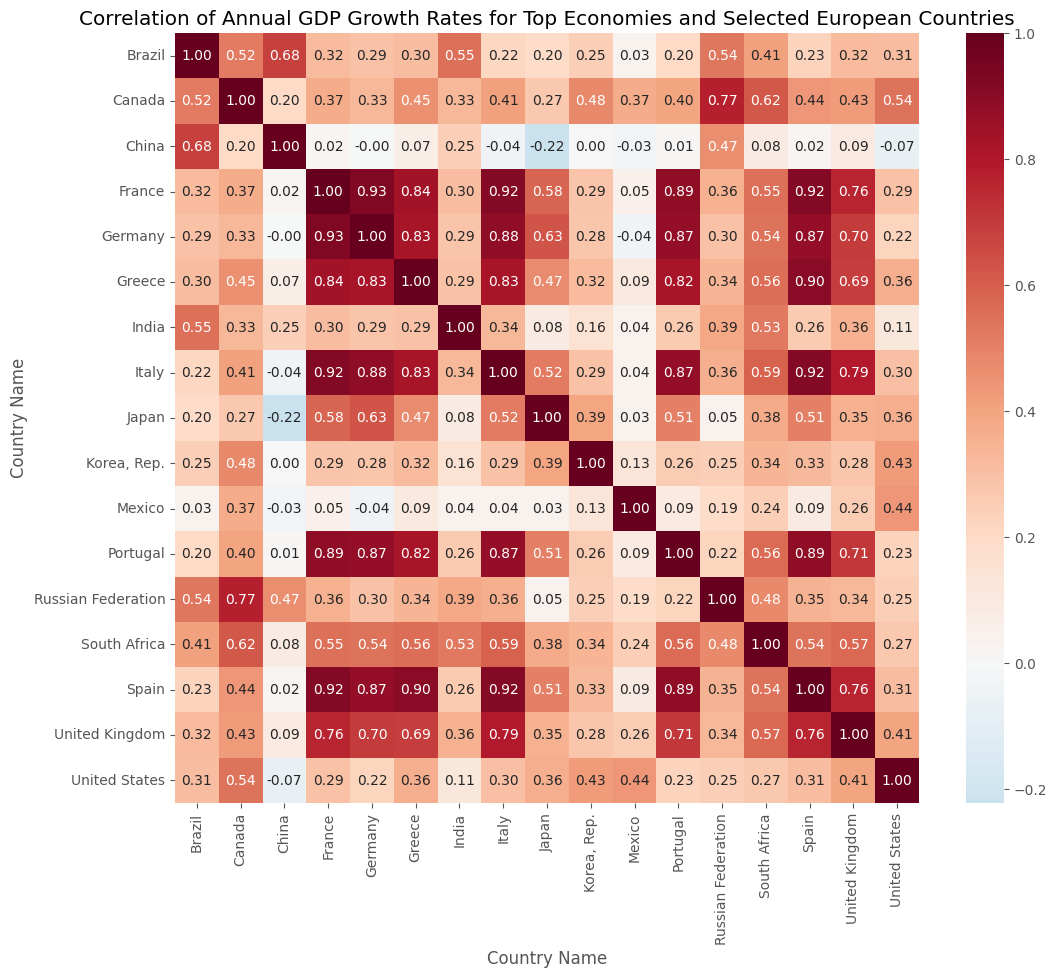

In [ ]:
countries_of_interest_gdp = top_15_countries_gdp['Country Name'].tolist()
countries_of_interest_gdp.extend(['Greece', 'Portugal', 'South Africa']) # Add Greece, Portugal, and South Africa
countries_of_interest_gdp.remove('Australia')

# Filter the main DataFrame for these countries
df_filtered = df[df['Country Name'].isin(countries_of_interest_gdp)].copy()

# Calculate GDP growth rate
df_filtered['Growth_Rate'] = df_filtered.groupby('Country Name')['Value'].pct_change() * 100

# Drop NaN values resulting from pct_change (first year for each country)
df_growth = df_filtered.dropna(subset=['Growth_Rate'])

# Pivot the DataFrame to have years as index and countries as columns
growth_pivot = df_growth.pivot(index='Year', columns='Country Name', values='Growth_Rate')

# Calculate the correlation matrix
country_growth_corr = growth_pivot.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(country_growth_corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation of Annual GDP Growth Rates for Top Economies and Selected European Countries')
plt.show()

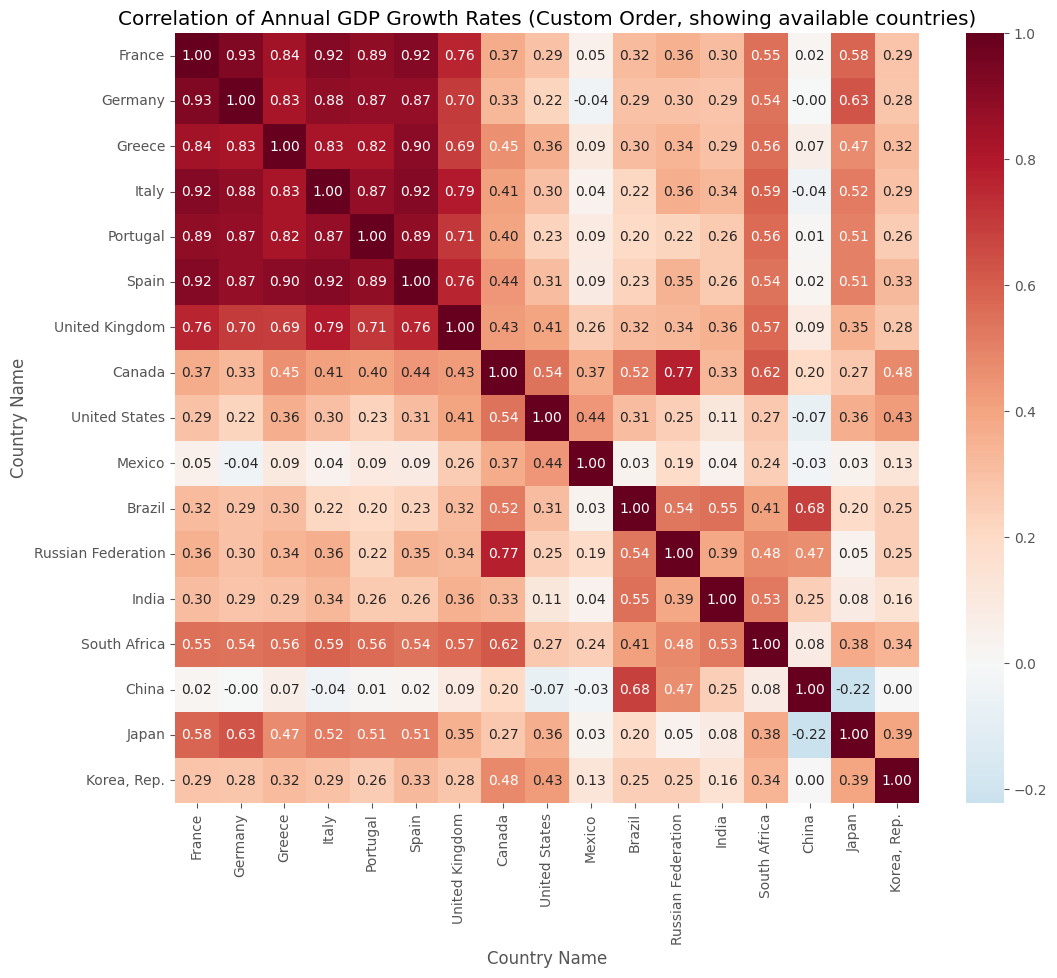

In [ ]:
custom_order = ['France', 'Germany','Greece','Italy','Portugal', 'Spain','United Kingdom', 'Canada', 'United States', 'Mexico','Brazil',
                'Russian Federation','India', 'South Africa', 'China', 'Japan', 'Korea, Rep.']

# Filter custom_order to only include countries that are actually present in the growth_pivot DataFrame
# This resolves the KeyError by ensuring we only try to access existing columns.
available_countries_in_pivot = [country for country in custom_order if country in growth_pivot.columns]

# Filter growth_pivot for countries in the (now filtered) custom_order and ensure column order
growth_pivot_reordered = growth_pivot[available_countries_in_pivot].copy()

country_growth_corr_reordered = growth_pivot_reordered.corr()

# Visualize with the new order
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(country_growth_corr_reordered, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation of Annual GDP Growth Rates (Custom Order, showing available countries)')
plt.show()

# Model Trainining

#Linear Regression (Baseline Model)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

def linreg (name, degree):
  # Training the model
  df_country = df[df['Country Name'] == name]

  X_country = df_country[['Year']].values
  y_country = df_country['Value'].values

  # Apply Polynomial Features
  poly = PolynomialFeatures(degree=degree)
  X_poly = poly.fit_transform(X_country)

  X_train, X_test, y_train, y_test = train_test_split(X_poly, y_country, test_size=0.2, shuffle=False)

  # Initialize the model
  lin_reg = LinearRegression()
  # Train the model using the pre-split data
  lin_reg.fit(X_train, y_train)

  # Make predictions on the test set
  y_pred_lin = lin_reg.predict(X_test)

  # Evaluate the error of the model
  mse_lin = mean_squared_error(y_test, y_pred_lin)
  mae_lin = mean_absolute_error(y_test, y_pred_lin)
  mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin)

  print(f"Polynomial Regression (Degree {degree}) Results for {name}:")
  print(f"Mean Squared Error (MSE): {mse_lin:.4f}")
  print(f"Test MAE: {mae_lin:.2f}")
  print(f"Test MAPE: {mape_lin:.2f}")

  # Forecast
  last_year = df_country['Year'].max()
  future_years_raw = np.array([[last_year + i] for i in range(1, 6)])
  future_years_poly = poly.transform(future_years_raw)
  future_forecast = lin_reg.predict(future_years_poly)

  # For plotting the trend line smoothly across all years
  all_years_raw = df_country['Year'].values.reshape(-1, 1)
  all_years_poly = poly.transform(all_years_raw)
  trend_line_predictions = lin_reg.predict(all_years_poly)

  plt.figure(figsize=(12, 7))

  # Plot Historical Data
  plt.scatter(df_country['Year'], y_country, color='black', label='Historical Data', alpha=0.6)

  # Plot Polynomial Trend Line
  plt.plot(all_years_raw, trend_line_predictions, color='blue', linestyle='-', linewidth=2, label=f'Polynomial Trend (Degree {degree})')

  # Plot Test Predictions
  test_years_raw = df_country['Year'].iloc[len(X_train):].values.reshape(-1,1)
  plt.scatter(test_years_raw, y_test, color='orange', label='Test Data (Actual)', zorder=5)
  plt.scatter(test_years_raw, y_pred_lin, color='green', marker='x', s=100, label='Test Predictions', zorder=5)

  # Plot Future Forecast
  plt.plot(future_years_raw, future_forecast, color='red', linestyle='--', marker='o', linewidth=2, label='5-Year Forecast')

  plt.title(f"GDP Forecast: {name} (Polynomial Regression Degree {degree})")
  plt.xlabel("Year")
  plt.ylabel("GDP")
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()

Polynomial Regression (Degree 1) Results for Greece:
Mean Squared Error (MSE): 5551520495345907793920.0000
Test MAE: 67852385085.21
Test MAPE: 0.32


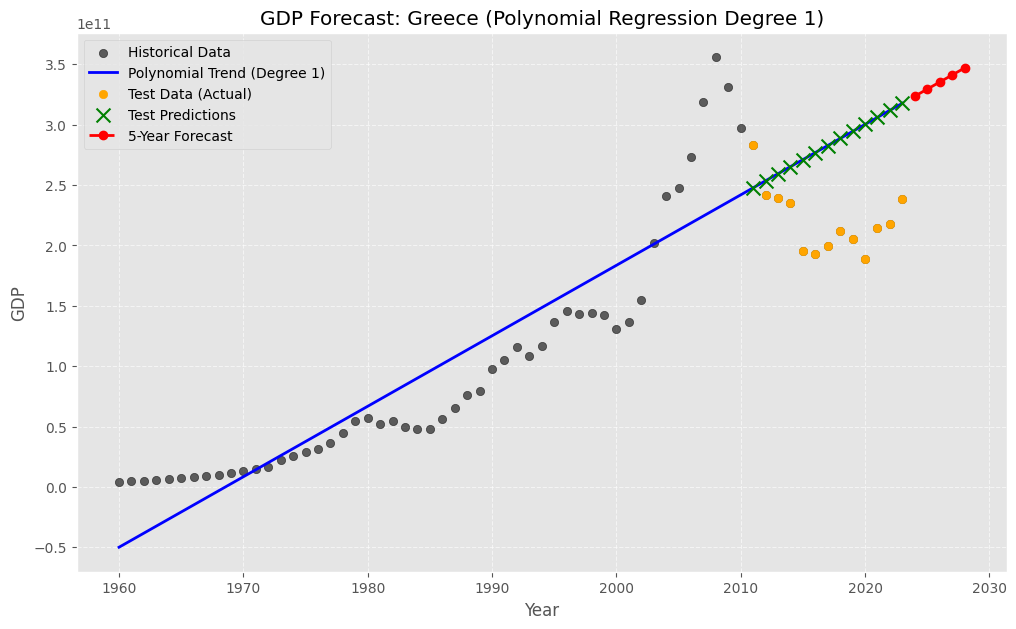

In [ ]:
linreg("Greece", 1)

Polynomial Regression (Degree 1) Results for Portugal:
Mean Squared Error (MSE): 401927296053410660352.0000
Test MAE: 16354437395.55
Test MAPE: 0.07


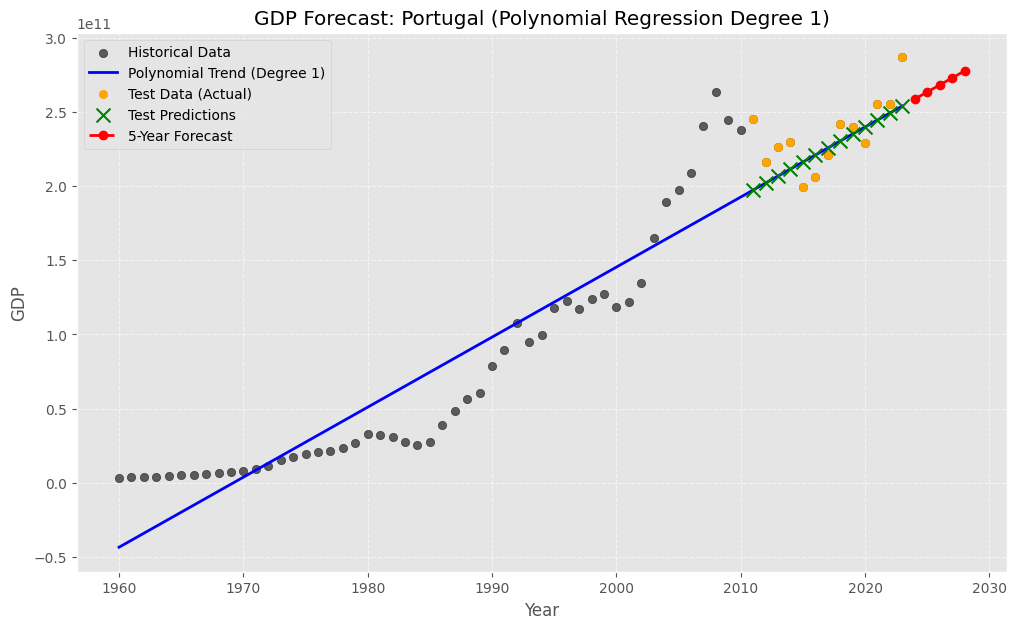

In [ ]:
linreg("Portugal", 1)

Polynomial Regression (Degree 1) Results for Germany:
Mean Squared Error (MSE): 92802508173684607287296.0000
Test MAE: 255063080726.04
Test MAPE: 0.07


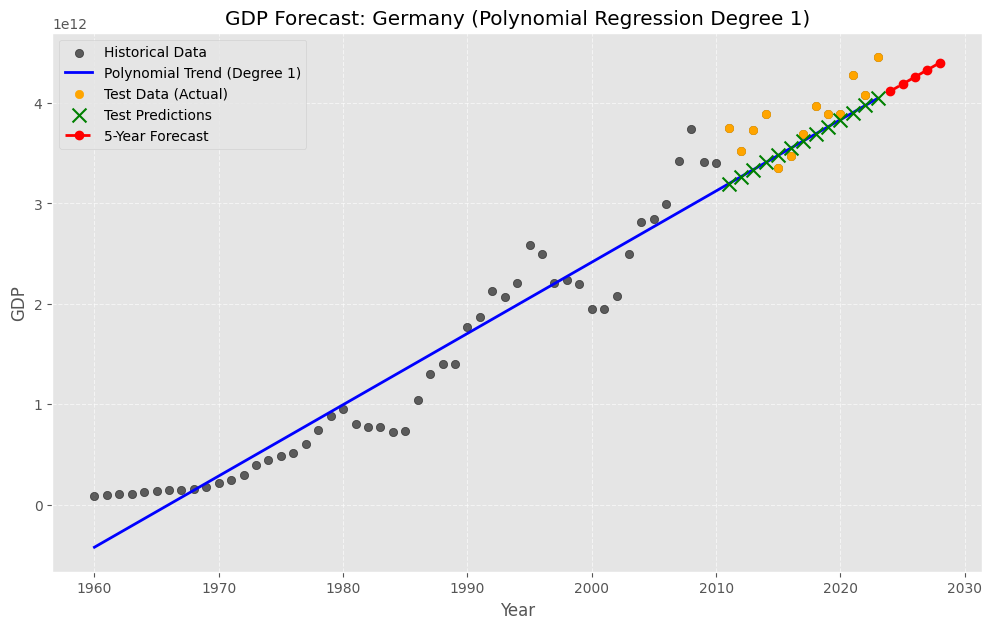

In [ ]:
linreg("Germany", 1)

# ARIMA

In [ ]:
def arima_forecast(name, best_order):
    df_arima = df[df['Country Name'] == name].copy()
    df_arima = df_arima.sort_values(by='Year')

    # Convert Year to datetime and set as index for time series analysis
    df_arima['Year'] = pd.to_datetime(df_arima['Year'], format='%Y')
    ts = df_arima.set_index('Year')['Value']

    # Split data into training and testing sets
    train_size = int(len(ts) * 0.8)
    train_data = ts.iloc[:train_size]
    test_data = ts.iloc[train_size:]

    # Initialize and fit the ARIMA model
    # (p,d,q) are the order of the ARIMA model. These can be optimized. For simplicity, we use common starting values.
    model = ARIMA(train_data, order=(5,1,0))
    model_fit = model.fit()

    # Make predictions on the test set
    start_index_pred = len(train_data)
    end_index_pred = len(ts) - 1
    y_pred_arima = model_fit.predict(start=start_index_pred, end=end_index_pred, typ='levels')

    # Evaluate the error of the model
    mse_arima = mean_squared_error(test_data, y_pred_arima)
    mae_arima = mean_absolute_error(test_data, y_pred_arima)
    mape_arima = mean_absolute_percentage_error(test_data, y_pred_arima)

    print(f"ARIMA Results")
    print(f"Mean Squared Error (MSE): {mse_arima:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_arima:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape_arima:.2f}")

    # Forecast future values (e.g., next 5 years)
    future_forecast_start_index = len(ts)
    future_forecast_end_index = len(ts) + 4 # For 5 years forecast
    future_forecast = model_fit.predict(start=future_forecast_start_index, end=future_forecast_end_index, typ='levels')
    forecast_years = pd.to_datetime(np.arange(ts.index.max().year + 1, ts.index.max().year + 6), format='%Y')

    # Plotting the results
    plt.figure(figsize=(12, 7))
    plt.plot(train_data.index, train_data.values, label='Training Data', color='black')
    plt.plot(test_data.index, test_data.values, label='Actual Test Data', color='orange')
    plt.plot(y_pred_arima.index, y_pred_arima.values, label='ARIMA Test Predictions', color='green', linestyle='--')
    plt.plot(forecast_years, future_forecast.values, label='ARIMA 5-Year Forecast', color='red', linestyle='-', marker='o')

    # Add vertical line for train/test split, similar to Prophet
    plt.axvline(x=train_data.index.max(), color='grey', linestyle='--', linewidth=2, label='Train/Test Split')

    plt.title(f"GDP Forecast: {name} (ARIMA Model)")
    plt.xlabel("Year")
    plt.ylabel("GDP (current USD)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [ ]:
from sklearn.model_selection import ParameterGrid
def optimize_arima(name, p_range, d_range, q_range):
    df_arima = df[df['Country Name'] == name].copy()
    df_arima = df_arima.sort_values(by='Year')

    # Convert Year to datetime and set as index
    df_arima['Year'] = pd.to_datetime(df_arima['Year'], format='%Y')
    ts = df_arima.set_index('Year')['Value']

    # Split data for training and validation
    train_size = int(len(ts) * 0.8)
    train_data = ts.iloc[:train_size]
    test_data = ts.iloc[train_size:]

    best_mae = float('inf')
    best_order = None

    print(f"\nOptimizing ARIMA for {name}...")

    # Grid search for p, d, q
    for p in p_range:
        for d in d_range:
            for q in q_range:
                order = (p, d, q)
                model = ARIMA(train_data, order=order)
                model_fit = model.fit()

                # Make predictions on the test set
                start_index_pred = len(train_data)
                end_index_pred = len(ts) - 1
                y_pred = model_fit.predict(start=start_index_pred, end=end_index_pred, typ='levels')

                mae = mean_absolute_error(test_data, y_pred)

                if mae < best_mae:
                   best_mae = mae
                   best_order = order


    print(f"Best ARIMA order for {name}: {best_order} with MAE: {best_mae:.2f}")
    return best_order, best_mae


Optimizing ARIMA for Greece...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency informat

Best ARIMA order for Greece: (0, 1, 3) with MAE: 59688961269.31
ARIMA Results
Mean Squared Error (MSE): 2943652211190098558976.0000
Mean Absolute Error (MAE): 50485866778.89
Mean Absolute Percentage Error (MAPE): 0.24


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.



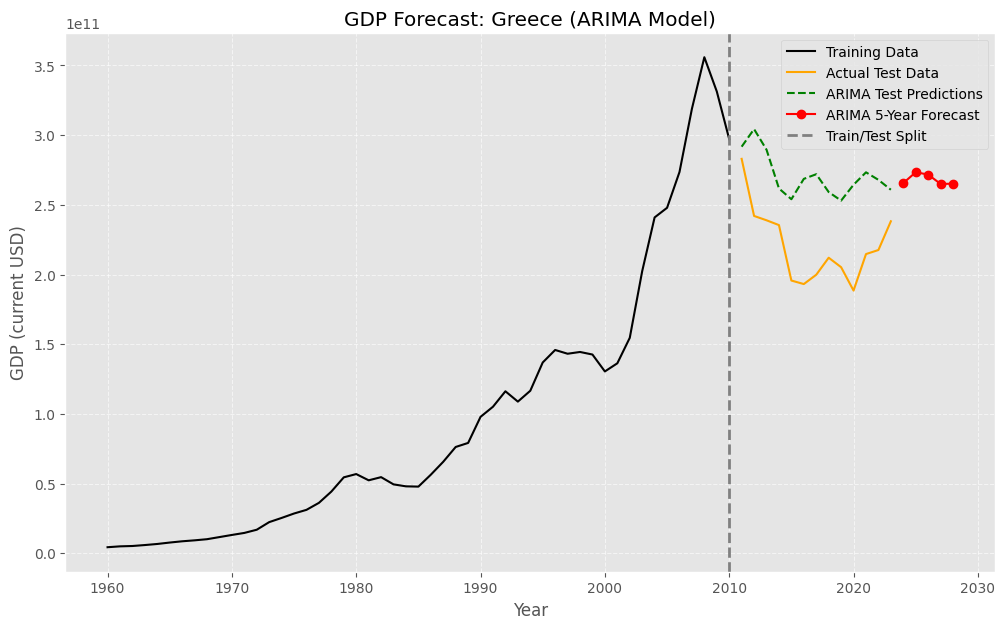

In [ ]:
best_oder,_ = optimize_arima("Greece", (0,3), (1,1), (0,3))
arima_forecast("Greece", best_oder)

On average, the ARIMA model's predictions deviated from the actual values by 24%. While not extremely low, it provides a quantitative measure of the model's accuracy. The plot visually confirms that the model captures the overall trend and some fluctuations in Greece's GDP fairly well.




Optimizing ARIMA for Portugal...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency YS-JAN will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency informat

Best ARIMA order for Portugal: (0, 1, 0) with MAE: 18044040671.35
ARIMA Results
Mean Squared Error (MSE): 1047667215160420990976.0000
Mean Absolute Error (MAE): 26340345178.41
Mean Absolute Percentage Error (MAPE): 0.12


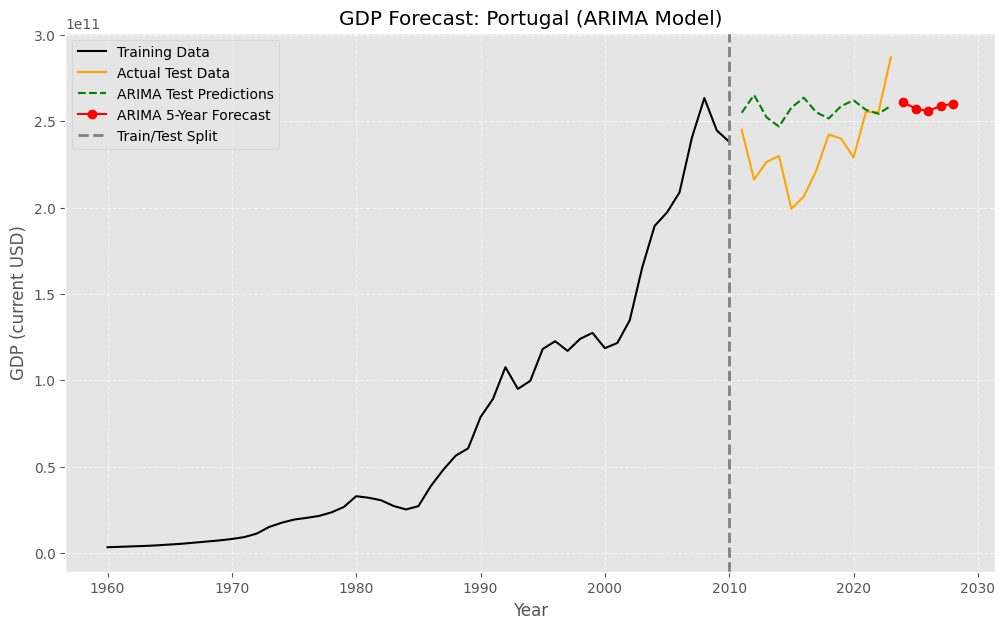

In [ ]:
best_oder,_ = optimize_arima("Portugal", (0,3), (1,1), (0,3))
arima_forecast("Portugal", best_oder)

On average, the ARIMA model's predictions deviated from the actual values by 12%. This result is low proving that the model has accurately captured the trend of Portugal's economy to a rather large extent.




Optimizing ARIMA for Germany...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

Best ARIMA order for Germany: (3, 1, 0) with MAE: 337042975601.62
ARIMA Results
Mean Squared Error (MSE): 184358240383161398722560.0000
Mean Absolute Error (MAE): 362812278669.99
Mean Absolute Percentage Error (MAPE): 0.09


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


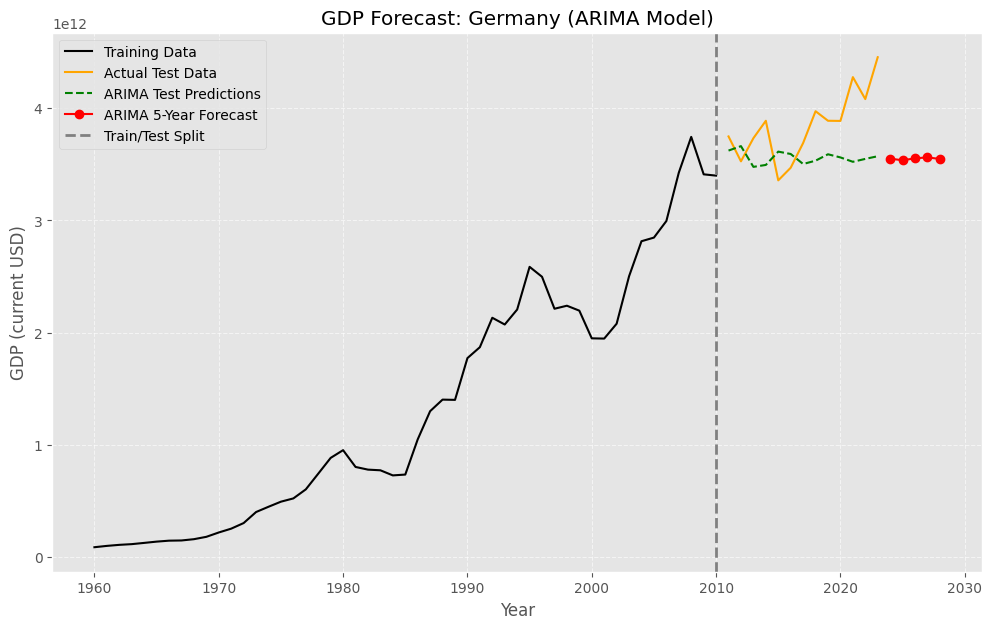

In [ ]:
best_oder,_ = optimize_arima("Germany", (0,3), (1,1), (0,3))
arima_forecast("Germany", best_oder)

On average, the ARIMA model's predictions deviated from the actual values by 9%. This result is extremely low proving that the model has accurately captured the trend of Germany's economy to an extremely large extent. This is also visually clear from the above graph.



# Prophet

In [ ]:
def prophet_forecast(name, changepoint_prior_scale):
    df_prophet = df[df['Country Name'] == name].copy()
    df_prophet = df_prophet.sort_values(by='Year')
    df_prophet['Year'] = pd.to_datetime(df_prophet['Year'], format='%Y')
    df_prophet = df_prophet.rename(columns={'Year': 'ds', 'Value': 'y'})

    # Split data into training and testing sets
    train_size = int(len(df_prophet) * 0.8)
    train_data = df_prophet.iloc[:train_size]
    test_data = df_prophet.iloc[train_size:]

    # Initialize and fit the Prophet model
    model = Prophet(yearly_seasonality=False,
      weekly_seasonality=False,
      daily_seasonality=False,
      changepoint_prior_scale=changepoint_prior_scale)
    model.fit(train_data)

    # Create a DataFrame for future predictions (including historical dates for evaluation)
    future_dates = model.make_future_dataframe(periods=len(test_data) + 5, freq='YS') # +5 for future forecast

    # Make predictions
    forecast = model.predict(future_dates)

    # Extract test predictions
    y_pred_prophet = forecast['yhat'].iloc[train_size : train_size + len(test_data)]

    # Evaluate the error of the model
    mse_prophet = mean_squared_error(test_data['y'], y_pred_prophet)
    mae_prophet = mean_absolute_error(test_data['y'], y_pred_prophet)
    mape_prophet = mean_absolute_percentage_error(test_data['y'], y_pred_prophet)

    print(f"Prophet Results for {name}:")
    print(f"Mean Squared Error (MSE): {mse_prophet:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_prophet:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape_prophet:.2f}")

    # Plotting the results
    plt.figure(figsize=(12, 7))
    plt.plot(train_data['ds'], train_data['y'], label='Training Data', color='black')
    plt.plot(test_data['ds'], test_data['y'], label='Actual Test Data', color='orange')
    plt.plot(test_data['ds'], y_pred_prophet, label='Prophet Test Predictions', color='green', linestyle='--')

    # Plot future forecast (the last 5 periods)
    future_forecast_prophet_dates = forecast['ds'].iloc[len(df_prophet):]
    future_forecast_prophet_values = forecast['yhat'].iloc[len(df_prophet):]
    plt.plot(future_forecast_prophet_dates, future_forecast_prophet_values, label='Prophet 5-Year Forecast', color='red', linestyle='-', marker='o')

    plt.title(f"GDP Forecast: {name} (Prophet Model)")
    plt.xlabel("Year")
    plt.ylabel("GDP (current USD)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [ ]:
possible_changepoint_prior_scales = [0.005, 0.01, 0.02, 0.05, 0.1]


Optimizing Prophet for Greece...
  Prophet with changepoint_prior_scale=0.005: MAPE=0.33
  Prophet with changepoint_prior_scale=0.010: MAPE=0.33
  Prophet with changepoint_prior_scale=0.020: MAPE=0.32
  Prophet with changepoint_prior_scale=0.050: MAPE=0.91
  Prophet with changepoint_prior_scale=0.100: MAPE=1.09
Best Prophet changepoint_prior_scale for Greece: 0.02 with MAPE: 0.32
Prophet Results for Greece:
Mean Squared Error (MSE): 5559045593197651689472.0000
Mean Absolute Error (MAE): 67903718020.03
Mean Absolute Percentage Error (MAPE): 0.32


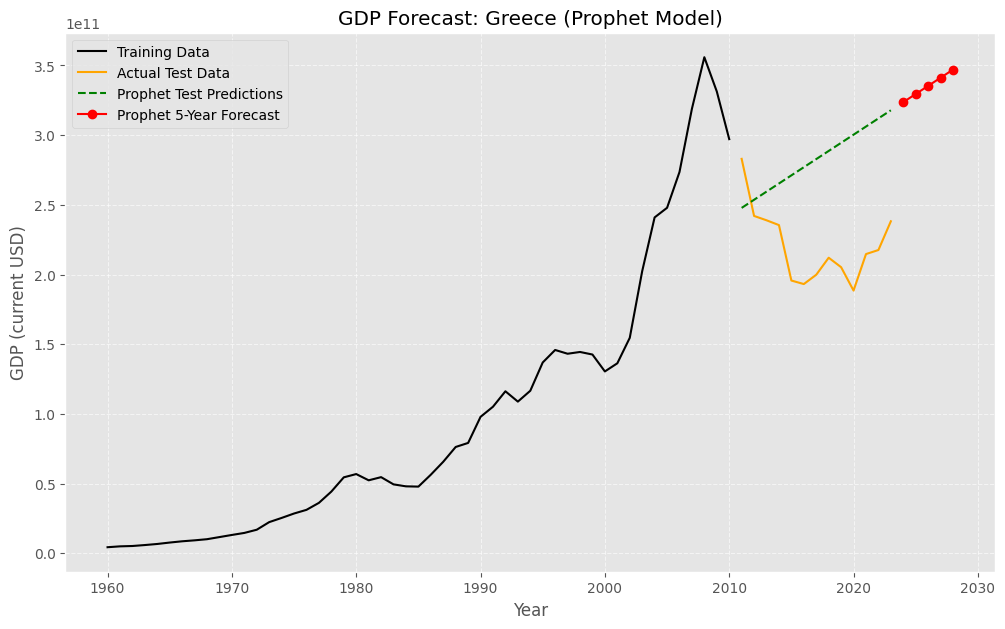

In [ ]:
def optimize_prophet(name, changepoint_prior_scale_range):
    df_prophet = df[df['Country Name'] == name].copy()
    df_prophet = df_prophet.sort_values(by='Year')
    df_prophet['Year'] = pd.to_datetime(df_prophet['Year'], format='%Y')
    prophet_data = df_prophet.rename(columns={'Year': 'ds', 'Value': 'y'})

    train_size = int(len(prophet_data) * 0.8)
    train_data = prophet_data.iloc[:train_size]
    test_data = prophet_data.iloc[train_size:]

    best_mape = float('inf')
    best_changepoint_prior_scale = None

    print(f"\nOptimizing Prophet for {name}...")

    for cps in changepoint_prior_scale_range:
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=cps
        )
        model.fit(train_data)

        future = model.make_future_dataframe(periods=len(test_data), freq='YS')
        forecast = model.predict(future)
        y_pred = forecast[forecast['ds'].isin(test_data['ds'])]['yhat']

        mape = mean_absolute_percentage_error(test_data['y'].values, y_pred.values)

        if mape < best_mape:
            best_mape = mape
            best_changepoint_prior_scale = cps

        print(f"  Prophet with changepoint_prior_scale={cps:.3f}: MAPE={mape:.2f}")

    print(f"Best Prophet changepoint_prior_scale for {name}: {best_changepoint_prior_scale} with MAPE: {best_mape:.2f}")
    return best_changepoint_prior_scale

# Example usage for Greece, using the updated possible_changepoint_prior_scales list
best_cps_greece = optimize_prophet("Greece", possible_changepoint_prior_scales)
prophet_forecast("Greece", best_cps_greece)


Optimizing Prophet for Portugal...
  Prophet with changepoint_prior_scale=0.005: MAPE=0.07
  Prophet with changepoint_prior_scale=0.010: MAPE=0.07
  Prophet with changepoint_prior_scale=0.020: MAPE=0.07
  Prophet with changepoint_prior_scale=0.050: MAPE=0.32
  Prophet with changepoint_prior_scale=0.100: MAPE=0.40
Best Prophet changepoint_prior_scale for Portugal: 0.02 with MAPE: 0.07
Prophet Results for Portugal:
Mean Squared Error (MSE): 403796038035190513664.0000
Mean Absolute Error (MAE): 16394661871.17
Mean Absolute Percentage Error (MAPE): 0.07


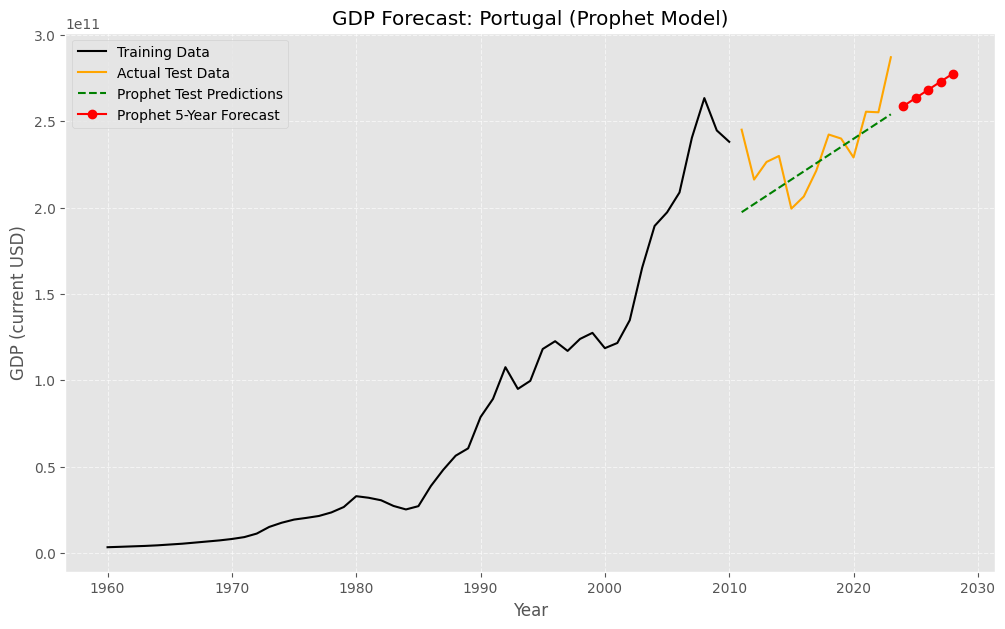

In [ ]:
best_cps_portugal = optimize_prophet("Portugal", possible_changepoint_prior_scales)
prophet_forecast("Portugal", best_cps_portugal)


Optimizing Prophet for Germany...
  Prophet with changepoint_prior_scale=0.005: MAPE=0.07
  Prophet with changepoint_prior_scale=0.010: MAPE=0.07
  Prophet with changepoint_prior_scale=0.020: MAPE=0.07
  Prophet with changepoint_prior_scale=0.050: MAPE=0.05
  Prophet with changepoint_prior_scale=0.100: MAPE=0.06
Best Prophet changepoint_prior_scale for Germany: 0.05 with MAPE: 0.05
Prophet Results for Germany:
Mean Squared Error (MSE): 49619865583783243677696.0000
Mean Absolute Error (MAE): 194640290086.35
Mean Absolute Percentage Error (MAPE): 0.05


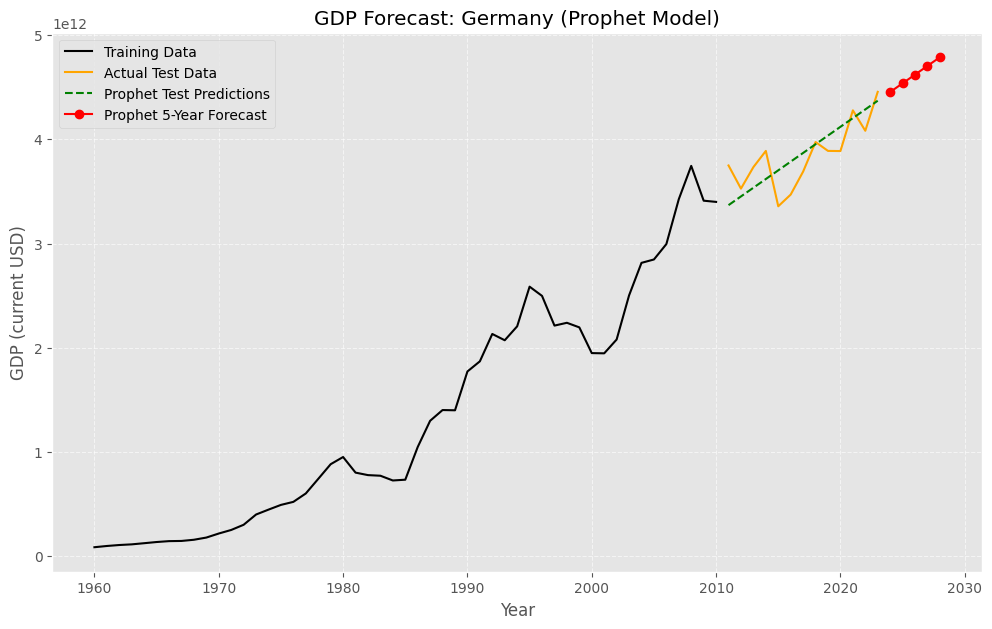

In [ ]:
best_cps_germany = optimize_prophet("Germany", possible_changepoint_prior_scales)
prophet_forecast("Germany", best_cps_germany)

# LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Helper function for creating sequences
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)): # Iterate from lookback to ensure enough data for each sequence
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def lstm_forecast(name, lookback, epochs, batch_size):
    df_country = df[df['Country Name'] == name].copy()
    df_country = df_country.sort_values(by='Year')

    # Prepare data for scaling
    gdp_values = df_country['Value'].values.reshape(-1, 1)

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    gdp_scaled = scaler.fit_transform(gdp_values)

    train_size = int(len(gdp_scaled) * 0.8)
    train_data_scaled = gdp_scaled[0:train_size, :]
    test_data_scaled = gdp_scaled[train_size:len(gdp_scaled), :]

    X_train_seq, y_train_seq = create_sequences(train_data_scaled, lookback)

    # Reshape for LSTM: [samples, time_steps, features]
    X_train_seq = X_train_seq.reshape(X_train_seq.shape[0], X_train_seq.shape[1], 1)

    print(f"Training LSTM for {name} with sequences of length {lookback}...")
    print(f"X_train_seq shape: {X_train_seq.shape}")
    print(f"y_train_seq shape: {y_train_seq.shape}")

    # Build LSTM model
    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(lookback, 1)),
        Dense(1)
    ])

    lstm_model.compile(optimizer='adam', loss='mse')

    # Train the model
    history = lstm_model.fit(
        X_train_seq, y_train_seq,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    # Create sequences for the test set from the full scaled data to ensure correct context
    # This ensures that the test sequences are built using the preceding 'lookback' values
    # from the entire dataset, not just the training set.
    full_sequences_start_idx = lookback
    # The actual test data starts from `train_size` in `gdp_scaled`.
    # The `X_test_seq` should correspond to values that predict `gdp_scaled[train_size:]`

    # Create sequences for the entire dataset (for correct test prediction context)
    X_full_seq, y_full_actual_scaled = create_sequences(gdp_scaled, lookback)

    # Determine the start index for the test set within the full sequences
    # The test set starts at `train_size` in the original `gdp_scaled` array.
    # The corresponding `y` in `y_full_actual_scaled` starts at `lookback`.
    # So, test predictions should start from `y_full_actual_scaled` at index `train_size - lookback`.
    test_start_idx_in_full_seq = train_size - lookback if train_size >= lookback else 0

    # Ensure we don't go out of bounds if train_size < lookback (though train_size is usually > lookback)
    if test_start_idx_in_full_seq < 0:
      test_start_idx_in_full_seq = 0

    X_test_seq = X_full_seq[test_start_idx_in_full_seq:]
    y_test_actual_scaled = y_full_actual_scaled[test_start_idx_in_full_seq:]

    # Reshape X_test_seq for prediction
    X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], X_test_seq.shape[1], 1)

    lstm_predictions_scaled = lstm_model.predict(X_test_seq, verbose=0)

    # Inverse transform predictions and actual test values
    y_test_unscaled = scaler.inverse_transform(y_test_actual_scaled.reshape(-1, 1)).flatten()
    lstm_predictions_unscaled = scaler.inverse_transform(lstm_predictions_scaled).flatten()

    # Calculate error
    lstm_mae = mean_absolute_error(y_test_unscaled, lstm_predictions_unscaled)
    lstm_mse = mean_squared_error(y_test_unscaled, lstm_predictions_unscaled)
    lstm_rmse = root_mean_squared_error(y_test_unscaled, lstm_predictions_unscaled)
    lstm_mape = mean_absolute_percentage_error(y_test_unscaled, lstm_predictions_unscaled)

    print(f"\n LSTM Performance for {name}:")
    print(f"  MAE:  {lstm_mae:.2f}")
    print(f"  MSE: {lstm_mse:.2f}")
    print(f"  MAPE:  {lstm_mape:.2f}")
    print(f"  RMSE:  {lstm_rmse:.2f}")

    # --- Future Forecasting (next 5 years) ---
    # Use the last 'lookback' values from the entire scaled dataset to start the forecast
    last_sequence_for_forecast = gdp_scaled[-lookback:].reshape(1, lookback, 1)

    future_forecast_scaled = []
    current_sequence_for_pred = list(gdp_scaled[-lookback:].flatten()) # Use last actual values

    for _ in range(5): # Forecast 5 steps into the future
        input_seq = np.array(current_sequence_for_pred[-lookback:]).reshape(1, lookback, 1)
        # Predict next value
        pred = lstm_model.predict(input_seq, verbose=0)[0, 0]
        future_forecast_scaled.append(pred)
        # Update sequence with the prediction to predict the next step
        current_sequence_for_pred.append(pred)

    future_forecast_unscaled = scaler.inverse_transform(np.array(future_forecast_scaled).reshape(-1, 1)).flatten()

    # Years for plotting
    all_years = df_country['Year'].values
    train_years_actual = all_years[:train_size] # Years corresponding to the training data portion
    test_years_actual = all_years[train_size:]  # Years corresponding to the testing data portion

    forecast_years = np.arange(df_country['Year'].max() + 1, df_country['Year'].max() + 6)

    # Visualize
    plt.figure(figsize=(14, 7))
    plt.plot(train_years_actual, scaler.inverse_transform(gdp_scaled[:train_size]).flatten(), label='Training Data', color='blue', markersize=5)
    plt.plot(test_years_actual, y_test_unscaled, label='Test Data (Actual)', color='green', markersize=6, linewidth=2)
    plt.plot(test_years_actual[lookback-1:], lstm_predictions_unscaled[lookback-1:], '^--', label='LSTM Test Predictions', color='red', markersize=7, linewidth=2) # Adjust start index if lookback is large
    plt.plot(forecast_years, future_forecast_unscaled, 'o-', label='LSTM 5-Year Forecast', color='purple', markersize=7, linewidth=2)
    plt.axvline(all_years[train_size - 1], color='black', linestyle=':', linewidth=2, label='Train/Test Split')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('GDP (current USD)', fontsize=12)
    plt.title(f'LSTM GDP Forecasting for {name}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.model_selection import ParameterGrid

def optimize_lstm(name, lookback_range, epochs_range, batch_size_range):
    df_country = df[df['Country Name'] == name].copy()
    df_country = df_country.sort_values(by='Year')

    gdp_values = df_country['Value'].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    gdp_scaled = scaler.fit_transform(gdp_values)

    train_size = int(len(gdp_scaled) * 0.8)
    total_scaled_data = gdp_scaled

    best_mape = float('inf')
    best_params = {}

    param_grid = {
        'lookback': lookback_range,
        'epochs': epochs_range,
        'batch_size': batch_size_range
    }

    print(f"\nOptimizing LSTM for {name}...")

    for params in ParameterGrid(param_grid):
        lookback = params['lookback']
        epochs = params['epochs']
        batch_size = params['batch_size']

        # Ensure lookback is smaller than train_size
        if train_size <= lookback:
            print(f"Skipping combination {params} as lookback ({lookback}) >= train_size ({train_size})")
            continue
        train_data_scaled = gdp_scaled[0:train_size, :]
        X_train_seq, y_train_seq = create_sequences(train_data_scaled, lookback)

        X_train_seq = X_train_seq.reshape(X_train_seq.shape[0], X_train_seq.shape[1], 1)

        lstm_model = Sequential([
            LSTM(50, activation='relu', input_shape=(lookback, 1)),
            Dense(1)
        ])
        lstm_model.compile(optimizer='adam', loss='mse')
        lstm_model.fit(X_train_seq, y_train_seq, epochs=epochs, batch_size=batch_size, verbose=0)

        # Evaluate on test set
        X_full_seq, y_full_seq = create_sequences(total_scaled_data, lookback)
        test_start_index_full_seq = len(X_train_seq)

        X_test_seq = X_full_seq[test_start_index_full_seq:]
        y_test_actual_scaled = y_full_seq[test_start_index_full_seq:]

        # Reshape X_test_seq for prediction
        X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], X_test_seq.shape[1], 1)

        lstm_predictions_scaled = lstm_model.predict(X_test_seq, verbose=0)

        y_test_unscaled = scaler.inverse_transform(y_test_actual_scaled.reshape(-1, 1)).flatten()
        lstm_predictions_unscaled = scaler.inverse_transform(lstm_predictions_scaled).flatten()

        current_mape = mean_absolute_percentage_error(y_test_unscaled, lstm_predictions_unscaled)

        if current_mape < best_mape:
            best_mape = current_mape
            best_params = params
            print(f"  Found new best params: {best_params} with MAPE: {best_mape:.2f}")

    print(f"Best LSTM parameters for {name}: {best_params} with MAPE: {best_mape:.2f}")
    return best_params

In [ ]:
lookback_range = [3, 5, 10, 15]
epochs_range = [20, 50, 100]
batch_size_range = [8, 16]


Optimizing LSTM for Germany...
  Found new best params: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.04


  Found new best params: {'batch_size': 16, 'epochs': 100, 'lookback': 3} with MAPE: 0.04
Best LSTM parameters for Germany: {'batch_size': 16, 'epochs': 100, 'lookback': 3} with MAPE: 0.04

Forecasting with optimized LSTM parameters:
Training LSTM for Germany with sequences of length 3...
X_train_seq shape: (48, 3, 1)
y_train_seq shape: (48,)

 LSTM Performance for Germany:
  MAE:  184283530552.93
  MSE: 52730412491396744216576.00
  MAPE:  0.05


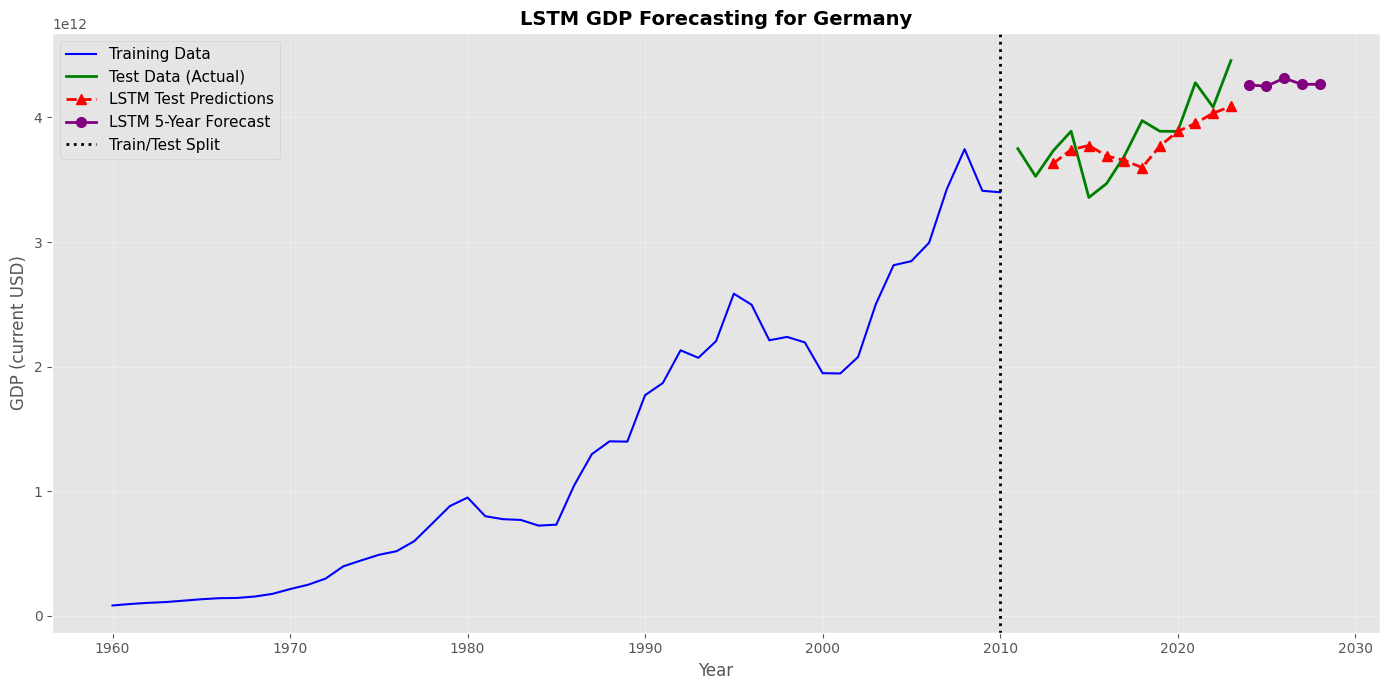

In [ ]:
best_lstm_params_germany = optimize_lstm("Germany", lookback_range, epochs_range, batch_size_range)
print("\nForecasting with optimized LSTM parameters:")
lstm_forecast(
    "Germany",
    lookback=best_lstm_params_germany['lookback'],
    epochs=best_lstm_params_germany['epochs'],
    batch_size=best_lstm_params_germany['batch_size'])



Optimizing LSTM for Greece...
  Found new best params: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.12
Best LSTM parameters for Greece: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.12

Forecasting with optimized LSTM parameters:
Training LSTM for Greece with sequences of length 3...
X_train_seq shape: (48, 3, 1)
y_train_seq shape: (48,)

 LSTM Performance for Greece:
  MAE:  52025709634.28
  MSE: 3641942909415716814848.00
  MAPE:  0.23


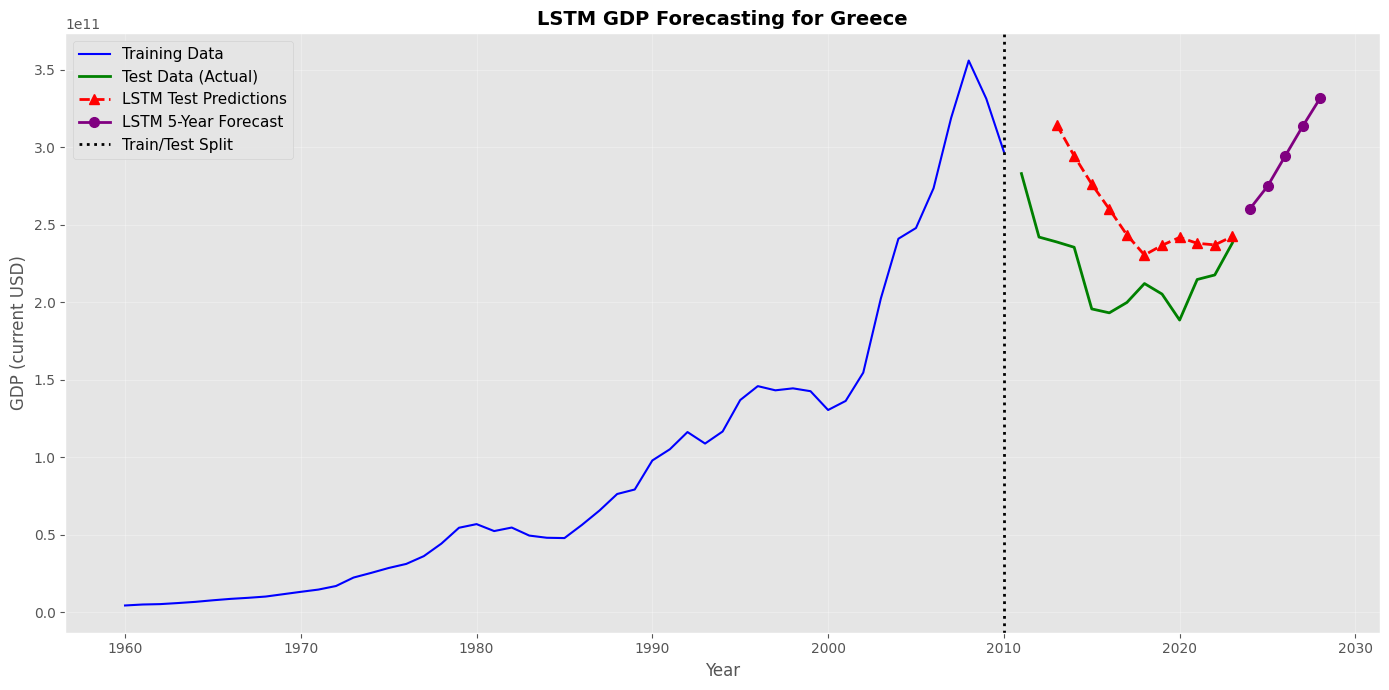

In [ ]:
best_lstm_params_greece = optimize_lstm("Greece", lookback_range, epochs_range, batch_size_range)
print("\nForecasting with optimized LSTM parameters:")
lstm_forecast(
    "Greece",
    lookback=best_lstm_params_greece['lookback'],
    epochs=best_lstm_params_greece['epochs'],
    batch_size=best_lstm_params_greece['batch_size'])



Optimizing LSTM for Portugal...
  Found new best params: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.10
  Found new best params: {'batch_size': 8, 'epochs': 50, 'lookback': 3} with MAPE: 0.09
  Found new best params: {'batch_size': 8, 'epochs': 100, 'lookback': 3} with MAPE: 0.09
Best LSTM parameters for Portugal: {'batch_size': 8, 'epochs': 100, 'lookback': 3} with MAPE: 0.09

Forecasting with optimized LSTM parameters:
Training LSTM for Portugal with sequences of length 3...
X_train_seq shape: (48, 3, 1)
y_train_seq shape: (48,)

 LSTM Performance for Portugal:
  MAE:  22000346407.03
  MSE: 677614301204024918016.00
  MAPE:  0.10


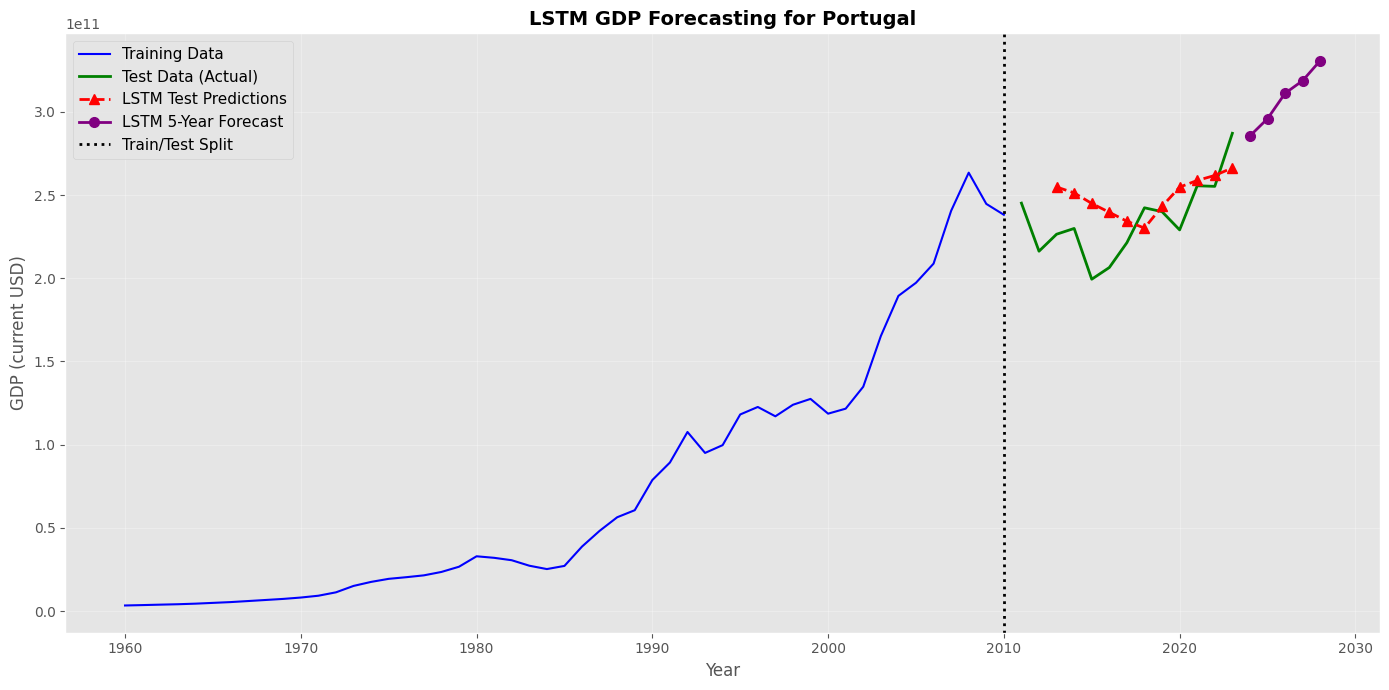

In [ ]:
best_lstm_params_portugal = optimize_lstm("Portugal", lookback_range, epochs_range, batch_size_range)
print("\nForecasting with optimized LSTM parameters:")
lstm_forecast(
    "Portugal",
    lookback=best_lstm_params_portugal['lookback'],
    epochs=best_lstm_params_portugal['epochs'],
    batch_size=best_lstm_params_portugal['batch_size'])

# Comparison

In [ ]:
def linear_mape(country):
  df_linear_reg= df[df['Country Name'] == country]
  df_linear_reg = df_linear_reg.sort_values(by='Year')
  train_size = int(len(df_linear_reg) * 0.8)
  train_data, test_data = df_linear_reg.iloc[:train_size], df_linear_reg.iloc[train_size:]
  model = LinearRegression()
  model.fit(train_data[['Year']], train_data['Value'])
  y_pred_test = model.predict(test_data[['Year']])
  linear_mape = mean_absolute_percentage_error(test_data['Value'], y_pred_test)
  return linear_mape

In [ ]:
import statsmodels.api as sm

def arima_mape(country):
  best_oder, _ = optimize_arima(country, (0,3), (1,1), (0,3))
  df_arima = df[df['Country Name'] == country].copy()
  df_arima = df_arima.sort_values(by='Year')
  df_arima['Year'] = pd.to_datetime(df_arima['Year'], format='%Y')
  ts = df_arima.set_index('Year')['Value']
  train_size = int(len(ts) * 0.8)
  train_data = ts.iloc[:train_size]
  test_data = ts.iloc[train_size:]

  with warnings.catch_warnings():
      warnings.simplefilter("ignore", category=UserWarning)
      model = ARIMA(train_data, order=best_oder)
      model_fit = model.fit()

  start_index_pred = len(train_data)
  end_index_pred = len(ts) - 1
  y_pred_arima = model_fit.predict(start=start_index_pred, end=end_index_pred, typ='levels')
  mape_arima_value = mean_absolute_percentage_error(test_data, y_pred_arima)
  print(f"ARIMA MAPE for {country} (using optimized order {best_oder}): {mape_arima_value:.2f}")
  return mape_arima_value

In [ ]:
def prophet_mape(country):
  best_cps = optimize_prophet(country, possible_changepoint_prior_scales)
  prophet_df_raw = df[df["Country Name"] == country].copy()
  prophet_df_raw = prophet_df_raw.sort_values(by='Year')

  prophet_data = pd.DataFrame()
  prophet_data['ds'] = pd.to_datetime(prophet_df_raw['Year'], format='%Y')
  prophet_data['y'] = prophet_df_raw['Value']

  train_size = int(len(prophet_data) * 0.8)
  train_data = prophet_data.iloc[:train_size]
  test_data = prophet_data.iloc[train_size:]

  model = Prophet(
      yearly_seasonality=False,
      weekly_seasonality=False,
      daily_seasonality=False,
      changepoint_prior_scale=best_cps # Use the optimized changepoint_prior_scale
  )
  model.fit(train_data)

  test_future = model.make_future_dataframe(periods=len(test_data), freq='YS')
  test_forecast = model.predict(test_future)
  y_pred_prophet = test_forecast[test_forecast['ds'].isin(test_data['ds'])]['yhat']

  mape_prophet = mean_absolute_percentage_error(test_data['y'].values, y_pred_prophet.values)
  print(f"Prophet MAPE for {country} (using optimized changepoint_prior_scale {best_cps}): {mape_prophet:.2f}")
  return mape_prophet

In [ ]:
def lstm_mape(country):
  # Optimize LSTM to find the best parameters
  # Using the same ranges for lookback, epochs, batch_size as in previous optimization calls
  best_params = optimize_lstm(country, lookback_range, epochs_range, batch_size_range)

  lookback = best_params['lookback']
  epochs = best_params['epochs']
  batch_size = best_params['batch_size']

  df_country = df[df['Country Name'] == country].copy()
  df_country = df_country.sort_values(by='Year')

  # Prepare data for scaling
  gdp_values = df_country['Value'].values.reshape(-1, 1)

  # Scale the data
  scaler = MinMaxScaler(feature_range=(0, 1))
  gdp_scaled = scaler.fit_transform(gdp_values)

  train_size = int(len(gdp_scaled) * 0.8)
  train_data_scaled = gdp_scaled[0:train_size, :]
  test_data_scaled = gdp_scaled[train_size:len(gdp_scaled), :]

  X_train_seq, y_train_seq = create_sequences(train_data_scaled, lookback)

  # Reshape for LSTM: [samples, time_steps, features]
  X_train_seq = X_train_seq.reshape(X_train_seq.shape[0], X_train_seq.shape[1], 1)

  # Build LSTM model
  lstm_model = Sequential([
      LSTM(50, activation='relu', input_shape=(lookback, 1)),
      Dense(1)
  ])

  lstm_model.compile(optimizer='adam', loss='mse')

  # Train the model
  lstm_model.fit(
      X_train_seq, y_train_seq,
      epochs=epochs,
      batch_size=batch_size,
      verbose=0
  )

  # Create sequences for the test set from the full scaled data to ensure correct context
  X_full_seq, y_full_actual_scaled = create_sequences(gdp_scaled, lookback)

  test_start_idx_in_full_seq = train_size - lookback if train_size >= lookback else 0
  if test_start_idx_in_full_seq < 0:
      test_start_idx_in_full_seq = 0

  X_test_seq = X_full_seq[test_start_idx_in_full_seq:]
  y_test_actual_scaled = y_full_actual_scaled[test_start_idx_in_full_seq:]

  # Reshape X_test_seq for prediction
  X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], X_test_seq.shape[1], 1)

  lstm_predictions_scaled = lstm_model.predict(X_test_seq, verbose=0)

  # Inverse transform predictions and actual test values
  y_test_unscaled = scaler.inverse_transform(y_test_actual_scaled.reshape(-1, 1)).flatten()
  lstm_predictions_unscaled = scaler.inverse_transform(lstm_predictions_scaled).flatten()

  # Calculate MAPE
  lstm_mape_value = mean_absolute_percentage_error(y_test_unscaled, lstm_predictions_unscaled)

  print(f"LSTM MAPE for {country} (using optimized params {best_params}): {lstm_mape_value:.2f}")
  return lstm_mape_value


Optimizing ARIMA for Greece...
Best ARIMA order for Greece: (0, 1, 3) with MAE: 59688961269.31
ARIMA MAPE for Greece (using optimized order (0, 1, 3)): 0.29

Optimizing Prophet for Greece...
  Prophet with changepoint_prior_scale=0.005: MAPE=0.33
  Prophet with changepoint_prior_scale=0.010: MAPE=0.33
  Prophet with changepoint_prior_scale=0.020: MAPE=0.32
  Prophet with changepoint_prior_scale=0.050: MAPE=0.91
  Prophet with changepoint_prior_scale=0.100: MAPE=1.09
Best Prophet changepoint_prior_scale for Greece: 0.02 with MAPE: 0.32
Prophet MAPE for Greece (using optimized changepoint_prior_scale 0.02): 0.32

Optimizing LSTM for Greece...
  Found new best params: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.19
  Found new best params: {'batch_size': 16, 'epochs': 20, 'lookback': 5} with MAPE: 0.11
Best LSTM parameters for Greece: {'batch_size': 16, 'epochs': 20, 'lookback': 5} with MAPE: 0.11
LSTM MAPE for Greece (using optimized params {'batch_size': 16, 'epochs': 20

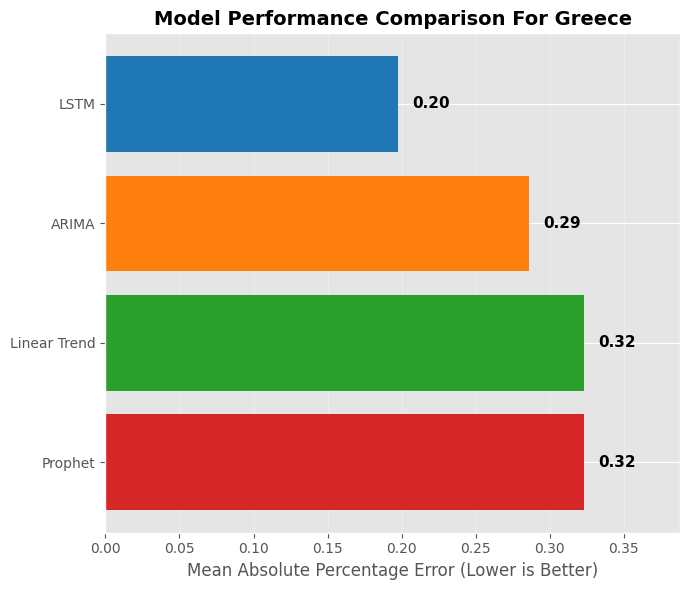


Optimizing ARIMA for Germany...
Best ARIMA order for Germany: (3, 1, 0) with MAE: 337042975601.62
ARIMA MAPE for Germany (using optimized order (3, 1, 0)): 0.08

Optimizing Prophet for Germany...
  Prophet with changepoint_prior_scale=0.005: MAPE=0.07
  Prophet with changepoint_prior_scale=0.010: MAPE=0.07
  Prophet with changepoint_prior_scale=0.020: MAPE=0.07
  Prophet with changepoint_prior_scale=0.050: MAPE=0.05
  Prophet with changepoint_prior_scale=0.100: MAPE=0.06
Best Prophet changepoint_prior_scale for Germany: 0.05 with MAPE: 0.05
Prophet MAPE for Germany (using optimized changepoint_prior_scale 0.05): 0.05

Optimizing LSTM for Germany...
  Found new best params: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.08
  Found new best params: {'batch_size': 8, 'epochs': 20, 'lookback': 5} with MAPE: 0.05
  Found new best params: {'batch_size': 8, 'epochs': 50, 'lookback': 3} with MAPE: 0.04
Best LSTM parameters for Germany: {'batch_size': 8, 'epochs': 50, 'lookback': 

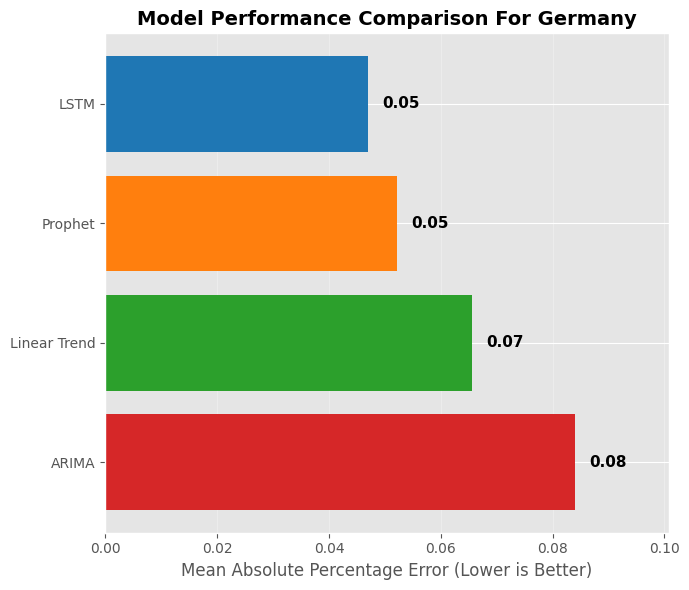


Optimizing ARIMA for Portugal...
Best ARIMA order for Portugal: (0, 1, 0) with MAE: 18044040671.35
ARIMA MAPE for Portugal (using optimized order (0, 1, 0)): 0.08

Optimizing Prophet for Portugal...
  Prophet with changepoint_prior_scale=0.005: MAPE=0.07
  Prophet with changepoint_prior_scale=0.010: MAPE=0.07
  Prophet with changepoint_prior_scale=0.020: MAPE=0.07
  Prophet with changepoint_prior_scale=0.050: MAPE=0.32
  Prophet with changepoint_prior_scale=0.100: MAPE=0.40
Best Prophet changepoint_prior_scale for Portugal: 0.02 with MAPE: 0.07
Prophet MAPE for Portugal (using optimized changepoint_prior_scale 0.02): 0.07

Optimizing LSTM for Portugal...
  Found new best params: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.08
Best LSTM parameters for Portugal: {'batch_size': 8, 'epochs': 20, 'lookback': 3} with MAPE: 0.08
LSTM MAPE for Portugal (using optimized params {'batch_size': 8, 'epochs': 20, 'lookback': 3}): 0.07

MODEL COMPARISON
       Model     MAPE
        L

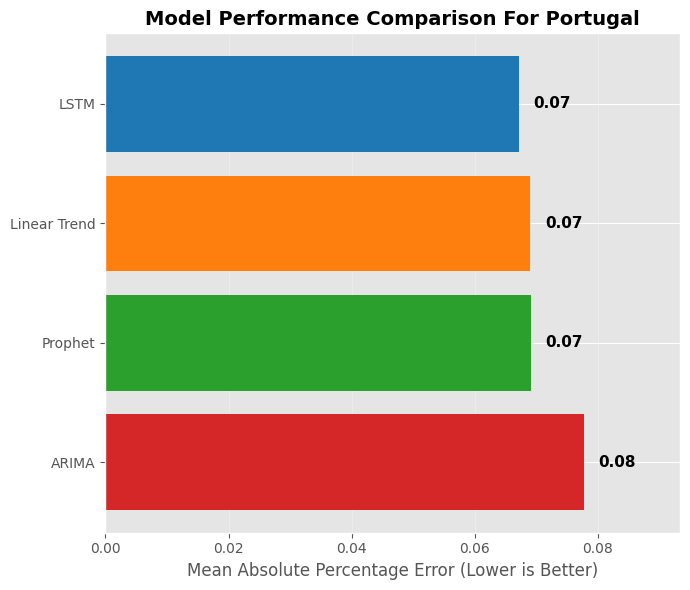

In [ ]:
countries = ['Greece', 'Germany', 'Portugal']
for country in countries:
  results = pd.DataFrame({
      'Model': ['Linear Trend', 'ARIMA', 'Prophet', 'LSTM'],
      'MAPE': [linear_mape(country), arima_mape(country), prophet_mape(country), lstm_mape(country)]
  })
  results = results.sort_values('MAPE')
  print("\nMODEL COMPARISON")
  print("="*60)
  print(results.to_string(index=False))
  print("="*60)
  print(f"\nBest Model: {results.iloc[0]['Model']} (MAPE = {results.iloc[0]['MAPE']:.2f})")
  # Visualize comparison
  fig, ax = plt.subplots(figsize=(7, 6)) # Reduced figure width further
  bars = ax.barh(results['Model'], results['MAPE'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
  ax.set_xlabel('Mean Absolute Percentage Error (Lower is Better)', fontsize=12)
  ax.set_title(f'Model Performance Comparison For {country}', fontsize=14, fontweight='bold')
  ax.invert_yaxis()
  ax.grid(True, alpha=0.3, axis='x')

  # Adjust x-axis limits dynamically to remove blank space
  max_mape_value = results['MAPE'].max()
  ax.set_xlim(0, max_mape_value * 1.2) # Set upper limit 20% higher than max MAPE for labels

  # Add values on bars, adjusted for dynamic x-axis
  for i, bar in enumerate(bars):
      width = bar.get_width()
      ax.text(width + (max_mape_value * 0.03), bar.get_y() + bar.get_height()/2, # Small, relative offset
              f'{width:.2f}', ha='left', va='center', fontsize=11, fontweight='bold')

  plt.tight_layout()
  plt.show()

For Greece all the models did not perform well which could be caused by the unpredictability of Greece's economy. In contrast, for both Portugal and Germany all the models performed really well, even the linear regression model, showing the predictability of these economies despite the 2009 economic crisis.

# Fine Tuning

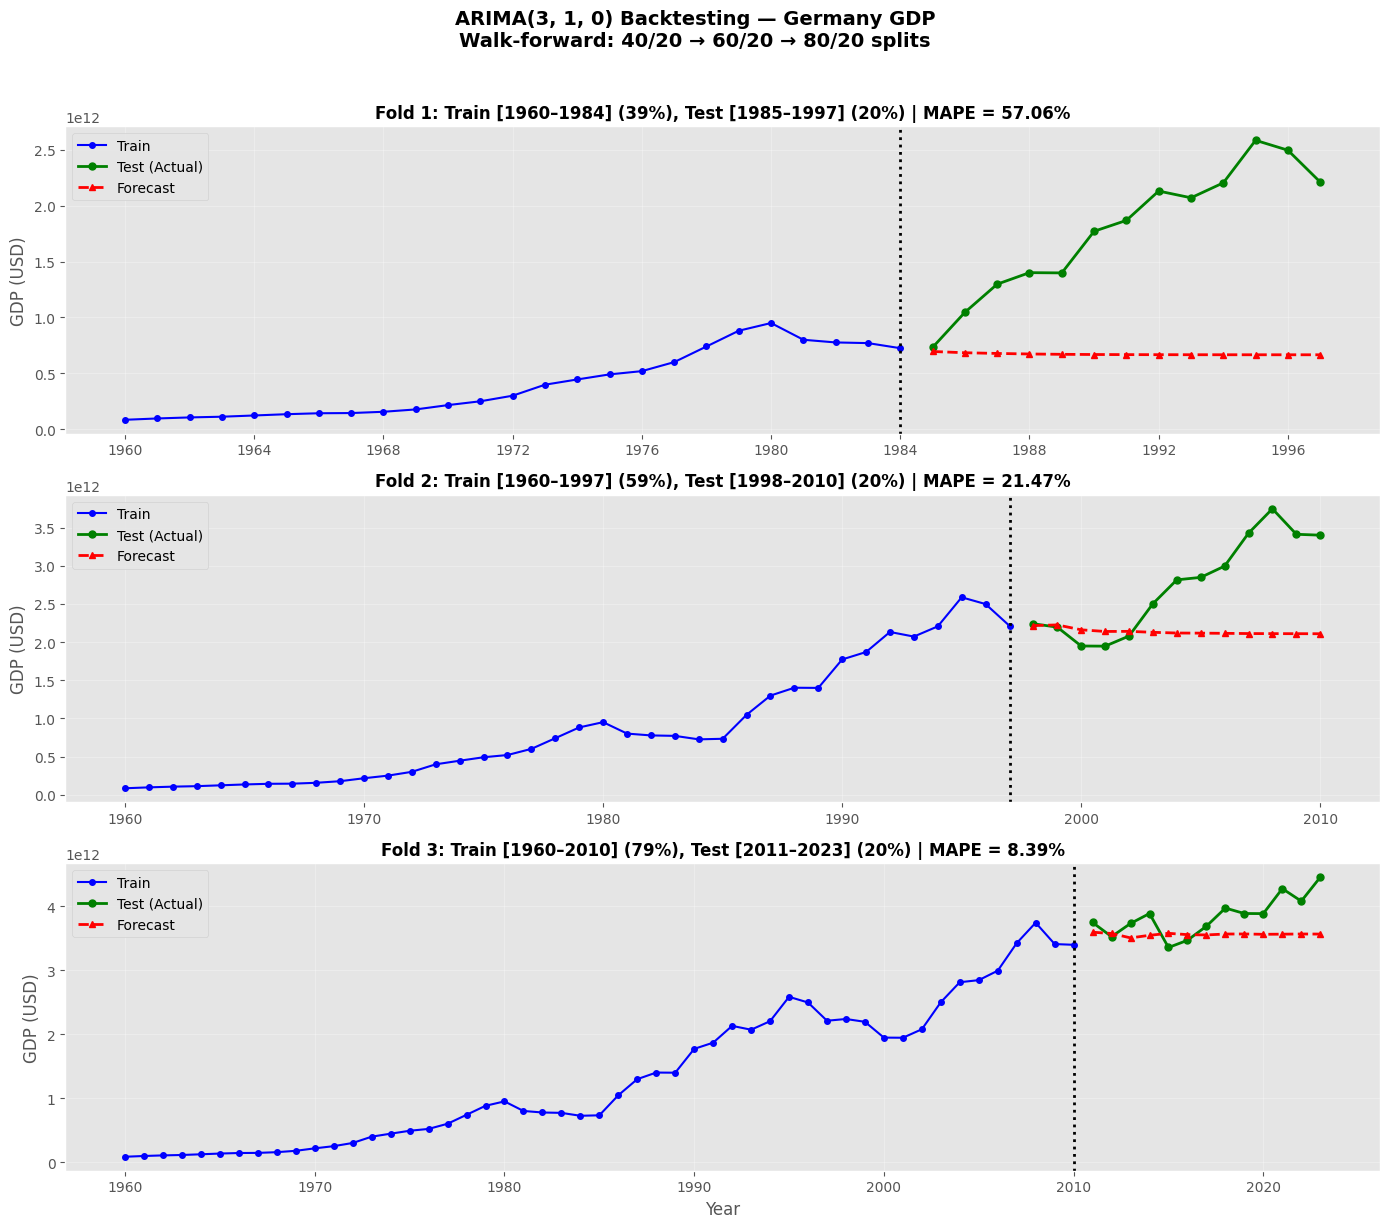


📊 ARIMA BACKTESTING RESULTS (Germany)
Fold 1 (40% train / 20% test) MAPE: 57.06%
Fold 2 (60% train / 20% test) MAPE: 21.47%
Fold 3 (80% train / 20% test) MAPE: 8.39%
Average MAPE across folds: 28.97%
Std Dev of MAPE:           20.56%


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# ── Backtesting with ARIMA — fixed percentage splits ──────────────────────
ARIMA_ORDER = (3, 1, 0)
n_folds     = 3
n           = len(arima_df)

# Define fold boundaries as (train_end, test_end) indices
fold_splits = [
    (int(n * 0.4), int(n * 0.6)),   # Fold 1: train 0–40%, test 40–60%
    (int(n * 0.6), int(n * 0.8)),   # Fold 2: train 0–60%, test 60–80%
    (int(n * 0.8), int(n * 1.0)),   # Fold 3: train 0–80%, test 80–100%
]

fig, axes = plt.subplots(n_folds, 1, figsize=(14, 12))
mape_scores = []

for fold, (train_end, test_end) in enumerate(fold_splits):
    train_fold = arima_df.iloc[:train_end]
    test_fold  = arima_df.iloc[train_end:test_end]
    test_size  = len(test_fold)

    # ── Fit ARIMA ─────────────────────────────────────────────────────────
    model        = ARIMA(train_fold['y'].values, order=ARIMA_ORDER)
    result       = model.fit()
    forecast_obj = result.get_forecast(steps=test_size)
    arima_yhat   = forecast_obj.predicted_mean
    conf_int     = forecast_obj.conf_int(alpha=0.05)

    # ── MAPE ──────────────────────────────────────────────────────────────
    mape_fold = mean_absolute_percentage_error(test_fold['y'].values, arima_yhat)
    mape_scores.append(mape_fold)

    # ── Plot ───────────────────────────────────────────────────────────────
    ax = axes[fold]

    ax.plot(train_fold['ds'], train_fold['y'],
            'o-', label='Train', color='blue', markersize=4)

    ax.plot(test_fold['ds'], test_fold['y'],
            'o-', label='Test (Actual)', color='green', markersize=5, linewidth=2)

    ax.plot(test_fold['ds'], arima_yhat,
            '^--', label='Forecast', color='red', markersize=5, linewidth=2)


    ax.axvline(train_fold['ds'].iloc[-1], color='black', linestyle=':', linewidth=2)

    # Annotate the split percentages on the plot
    train_pct = int(train_end / n * 100)
    ax.set_title(
        f'Fold {fold+1}: Train [1960–{train_fold["ds"].dt.year.max()}] ({train_pct}%), '
        f'Test [{test_fold["ds"].dt.year.min()}–{test_fold["ds"].dt.year.max()}] (20%) '
        f'| MAPE = {mape_fold*100:.2f}%',
        fontsize=12, fontweight='bold'
    )
    ax.set_ylabel('GDP (USD)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Year')
plt.suptitle(f'ARIMA{ARIMA_ORDER} Backtesting — Germany GDP\n'
             f'Walk-forward: 40/20 → 60/20 → 80/20 splits',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print("\n📊 ARIMA BACKTESTING RESULTS (Germany)")
print("=" * 50)
fold_labels = ["40% train / 20% test", "60% train / 20% test", "80% train / 20% test"]
for i, (mape, label) in enumerate(zip(mape_scores, fold_labels)):
    print(f"Fold {i+1} ({label}) MAPE: {mape*100:.2f}%")
print("=" * 50)
print(f"Average MAPE across folds: {np.mean(mape_scores)*100:.2f}%")
print(f"Std Dev of MAPE:           {np.std(mape_scores)*100:.2f}%")